For each benchmark, we have a model, or a model + agent harness, scored on which item, in which trial, and with what score in `[0, 1]`.

Data structure:
| Table | Grain | Joins |
|---|---|---|
| `benchmarks.parquet` | 1 row per benchmark | `benchmark_id` |
| `subjects.parquet` | 1 row per evaluated model/agent | `subject_id` |
| `items.parquet` | 1 row per task, with prompt, grading criterion and verifier | `item_id` |
| `response.parquet` | 1 row per subject × item × trial × test condition | `subject_id`, `item_id`, `response_id` |
| `traces.parquet` | 1 row per response with the raw model output | `response_id` |
| `assets.parquet` | 1 row per binary asset (MathArena images only) | `asset_id` ← `items.asset_manifest` |


## Setup

In [1]:
import json
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA = ROOT / "data"
BENCHMARKS = sorted(p.name for p in DATA.iterdir() if (p / "benchmarks.parquet").exists())
TABLES = ["benchmarks", "subjects", "items", "response", "traces", "assets"]

In [5]:
# Helper functions
# Several columns pack structured data into strings:
# `item_features` / `subject_features_extra` / `benchmark_features` use `key=value;key=value`, while
# `grading_criterion`, `verifier`, `response_scale` and `asset_manifest` are JSON.

def load(bench, table, columns=None):
    """Read one benchmark table; None if the benchmark doesn't ship it."""
    path = DATA / bench / f"{table}.parquet"
    return pd.read_parquet(path, columns=columns) if path.exists() else None


def kv(s):
    """Parse 'k=v;k=v' into a dict."""
    if not isinstance(s, str):
        return {}
    return dict(part.split("=", 1) for part in s.split(";") if "=" in part)


def kv_frame(series):
    return pd.DataFrame([kv(s) for s in series], index=series.index)


def parse_json(s):
    return json.loads(s) if isinstance(s, str) and s.strip() else None


def short(x, n=60):
    x = str(x).replace("\n", " ⏎ ")
    return x if len(x) <= n else x[: n - 1] + "…"


def null_report(df):
    """Per-column completeness and cardinality."""
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "non_null_%": (df.notna().mean() * 100).round(1),
        "n_unique": [df[c].nunique() if df[c].map(type).ne(list).all() else np.nan for c in df],
        "example": [short(df[c].dropna().iloc[0]) if df[c].notna().any() else "" for c in df],
    })


def barh(ax, counts, title, xlabel="count", top=20):
    counts = counts.head(top)[::-1]
    ax.barh([short(i, 40) for i in counts.index], counts.values, color=BLUE, height=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)


def hist(ax, values, title, xlabel, bins=40, logx=False,  label=None, histtype="bar"):
    values = pd.Series(values).dropna()
    if logx:
        values = values[values > 0]
        bins = np.logspace(np.log10(values.min()), np.log10(values.max()), bins)
        ax.set_xscale("log")
    ax.hist(values, bins=bins, label=label, histtype=histtype,
            linewidth=2 if histtype == "step" else 0, edgecolor=SURFACE if histtype == "bar" else color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("count")


def panels(n, width=5.2, height=3.4):
    fig, axes = plt.subplots(1, n, figsize=(width * n, height), squeeze=False)
    return fig, axes[0]


def subject_labels(subjects):
    """display_name, suffixed with the harness when a benchmark mixes harnesses."""
    label = subjects.display_name.astype(str)
    if subjects.harness.nunique() > 1:
        label = label + " · " + subjects.harness.fillna("?")
    return pd.Series(label.values, index=subjects.subject_id)


def item_category(items):
    """First item_features key with a useful number of categories (2–60), for score breakdowns."""
    feats = kv_frame(items.item_features)
    for col in feats:
        if 2 <= feats[col].nunique() <= 60:
            return col, feats[col]
    return None, None

In [ ]:
# Analysis helper functions
def eda_benchmarks(bench):
    row = load(bench, "benchmarks").iloc[0]
    display(Markdown(f"**{row['name']}** — {row.one_line_description}"))
    print(textwrap.fill(str(row.description), 120), "\n")
    display(row.drop(["description", "one_line_description"]).to_frame("value"))
    extra = kv(row.benchmark_features)
    if extra:
        print("benchmark_features:", extra)


def eda_subjects(bench):
    s = load(bench, "subjects")
    print(f"{len(s)} subjects · subject_id unique: {s.subject_id.is_unique} · "
          f"distinct normalized_name: {s.normalized_name.nunique()}")
    display(null_report(s))
    extra = kv_frame(s.subject_features_extra)
    if not extra.empty:
        print("subject_features_extra keys:", {c: extra[c].nunique() for c in extra})

    plots = [("provider", s.provider.fillna("(missing)").value_counts())]
    if s.harness.nunique() > 1:
        plots.append(("harness", s.harness.fillna("(missing)").value_counts()))
    if s.reasoning_effort.notna().any():
        plots.append(("reasoning_effort", s.reasoning_effort.fillna("(missing)").value_counts()))
    dates = pd.to_datetime(s.release_date, errors="coerce").dropna()
    if len(s) < 3:
        display(s.drop(columns=["subject_features_extra"]))
        return s
    fig, axes = panels(len(plots) + (len(dates) > 0))
    for ax, (col, counts) in zip(axes, plots):
        barh(ax, counts, f"Subjects by {col}")
    if len(dates):
        hist(axes[-1], dates, "Model release dates", "release_date", bins=min(20, max(len(dates) // 2, 5)))
        axes[-1].tick_params(axis="x", rotation=30)
    fig.tight_layout()
    plt.show()
    display(s.drop(columns=["subject_features_extra"]).head(8))
    return s


def eda_items(bench):
    it = load(bench, "items")
    print(f"{len(it):,} items · item_id unique: {it.item_id.is_unique} · raw_item_id unique: {it.raw_item_id.is_unique} · "
          f"duplicate content_hash: {it.content_hash.duplicated().sum()}")
    display(null_report(it))

    verifier = it.verifier.map(parse_json)
    vclass = verifier.map(lambda d: d.get("class") if d else None).fillna("(missing)")
    criterion = it.grading_criterion.map(parse_json)
    ref = criterion.map(lambda d: d.get("reference_answer") if d else None)
    ref_text = ref.map(lambda x: x if isinstance(x, str) else json.dumps(x) if x is not None else None)
    print("grading_criterion keys:", pd.Series([k for d in criterion.dropna() for k in d]).value_counts().to_dict())
    print("verifier keys:", pd.Series([k for d in verifier.dropna() for k in d]).value_counts().to_dict())
    print("grading rules:", {short(k, 90): v for k, v in
                             criterion.map(lambda d: d.get("rule") if d else None).value_counts().head(4).items()})

    feats = kv_frame(it.item_features)
    if not feats.empty:
        display(pd.DataFrame({
            "n_unique": feats.nunique(),
            "non_null": feats.notna().sum(),
            "top_values": [dict(feats[c].value_counts().head(4)) for c in feats],
        }).rename_axis("item_features key"))

    content_len = it.content.str.len()
    ref_len = ref_text.str.len()
    cat_name, cat = item_category(it)
    print("verifier class:", vclass.value_counts().to_dict())
    logx = content_len.max() / content_len.median() > 20
    n = 2 + (vclass.nunique() > 1) + (cat is not None)
    fig, axes = panels(n)
    hist(axes[0], content_len, "Prompt length", "characters" + (" (log)" if logx else ""), logx=logx)
    hist(axes[1], ref_len, "Reference answer length", "characters (log)", logx=True)
    k = 2
    if vclass.nunique() > 1:
        barh(axes[k], vclass.value_counts(), "Verifier class")
        k += 1
    if cat is not None:
        counts = cat.value_counts()
        barh(axes[k], counts, f"Items by {cat_name}" + (" (top 15)" if len(counts) > 15 else ""), top=15)
    fig.tight_layout()
    plt.show()

    ex = it.iloc[0]
    print(f"--- example item {ex.raw_item_id} ---")
    print(textwrap.shorten(ex.content, 700, placeholder=" …"))
    print("reference answer:", short(ref_text.iloc[0], 300))
    print("verifier:", short(ex.verifier, 300))
    return it


def eda_responses(bench):
    r = load(bench, "response")
    s = load(bench, "subjects")
    it = load(bench, "items", ["item_id", "item_features"])
    labels = subject_labels(s)
    cell_keys = ["subject_id", "item_id", "test_condition"]
    print(f"{len(r):,} responses · {r.subject_id.nunique()} subjects × {r.item_id.nunique():,} items · "
          f"trials {r.trial.min()}–{r.trial.max()} · response_id unique: {r.response_id.is_unique}")
    print(f"missing scores: {r.response.isna().sum():,} · duplicate (subject, item, trial, condition): "
          f"{r.duplicated(cell_keys + ['trial']).sum()}")
    print("test_condition:", r.test_condition.value_counts(dropna=False).to_dict())
    print("interactors:", r.interactors.value_counts(dropna=False).head(3).to_dict())
    print(f"orphans — subjects not in subjects table: {(~r.subject_id.isin(s.subject_id)).sum()}, "
          f"items not in items table: {(~r.item_id.isin(it.item_id)).sum()}")

    trials_per_cell = r.groupby(cell_keys, dropna=False).size().value_counts().sort_index()
    cell = r.groupby(["subject_id", "item_id"]).response.mean()
    matrix = cell.unstack()
    fill = matrix.notna().mean().mean()
    print(f"subject × item matrix: {matrix.shape[0]} × {matrix.shape[1]:,}, {fill:.1%} of cells observed")

    varied_trials = len(trials_per_cell) > 1
    if not varied_trials:
        print(f"every cell has exactly {trials_per_cell.index[0]} trial(s)")
    fig, axes = panels(3 if varied_trials else 2)
    values = r.response.dropna()
    if values.nunique() <= 30:
        vc = values.round(3).value_counts().sort_index()
        axes[0].bar(vc.index.astype(str), vc.values, color=BLUE, edgecolor=SURFACE)
        axes[0].tick_params(axis="x", rotation=90 if len(vc) > 8 else 0)
        axes[0].set_title("Score distribution (all responses)")
        axes[0].set_xlabel("response")
    else:
        hist(axes[0], values, "Score distribution (all responses)", "response")
    axes[0].grid(axis="x", visible=False)
    if varied_trials:
        axes[1].bar(trials_per_cell.index.astype(str), trials_per_cell.values, color=BLUE, edgecolor=SURFACE)
        axes[1].set_yscale("log")
        axes[1].set_title("Trials per subject × item cell")
        axes[1].set_xlabel("number of trials")
        axes[1].set_ylabel("cells (log)")
        axes[1].grid(axis="x", visible=False)
        if len(trials_per_cell) > 15:
            axes[1].set_xticks(range(0, len(trials_per_cell), 3))
    hist(axes[-1], matrix.mean(axis=0), "Item difficulty (mean score per item)", "mean score over subjects", bins=25)
    fig.tight_layout()
    plt.show()

    if matrix.shape[0] > 1:
        _response_matrix_plots(matrix, labels)

    cat_name, cat = item_category(it)
    if cat is not None:
        by_cat = (r.merge(pd.DataFrame({"item_id": it.item_id, cat_name: cat}), on="item_id")
                  .groupby(cat_name).response.agg(["mean", "size"]).sort_values("mean", ascending=False))
        fig, axes = panels(1, width=7, height=max(2.5, 0.28 * len(by_cat)))
        barh(axes[0], by_cat["mean"], f"Mean score by {cat_name}", "mean score", top=60)
        axes[0].set_xlim(0, 1)
        fig.tight_layout()
        plt.show()
    return r


def _response_matrix_plots(matrix, labels):
    subj_mean = matrix.mean(axis=1).sort_values(ascending=False)
    item_order = matrix.mean(axis=0).sort_values(ascending=False).index
    m = matrix.loc[subj_mean.index, item_order]

    fig, ax = plt.subplots(figsize=(12, max(3, min(9, 0.09 * len(m)))))
    im = ax.imshow(np.ma.masked_invalid(m.values), aspect="auto", cmap=SEQ, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title("Response matrix — subjects (rows, best first) × items (columns, easiest first); blank = not observed")
    ax.set_xlabel("items")
    ax.set_ylabel("subjects")
    ax.set_yticks([])
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="mean score")
    fig.tight_layout()
    plt.show()

    fig, axes = panels(2, width=6.5, height=3.4)
    hist(axes[0], matrix.notna().sum(axis=1), "Items observed per subject", "items", bins=25)
    hist(axes[1], subj_mean, "Subject ability (mean score per subject)", "mean score over observed items", bins=25)
    fig.tight_layout()
    plt.show()

    table = pd.DataFrame({
        "subject": labels.reindex(subj_mean.index).values,
        "mean_score": subj_mean.round(3).values,
        "n_items": matrix.notna().sum(axis=1).reindex(subj_mean.index).values,
    })
    min_items = 20
    dropped = (table.n_items < min_items).sum()
    table = table[table.n_items >= min_items]
    show = table if len(table) <= 20 else pd.concat([table.head(10), table.tail(10)])
    print("Subjects by mean score" + ("" if len(table) <= 20 else " (top 10 / bottom 10)")
          + (f", excluding {dropped} subjects with < {min_items} observed items" if dropped else "") + "."
          + " Raw means are not comparable when subjects saw different items:")
    display(show.reset_index(drop=True))


def eda_traces(bench, responses):
    path = DATA / bench / "traces.parquet"
    if not path.exists():
        print("No traces.parquet for this benchmark.")
        return None
    t = pq.read_table(path, columns=["response_id", "trace"])
    col = t["trace"]
    tr = pd.DataFrame({
        "response_id": t["response_id"].to_pandas(),
        "chars": pc.utf8_length(col).to_pandas(),
        "lines": pc.add(pc.count_substring(col, "\n"), 1).to_pandas(),
        "files_in_diff": pc.count_substring(col, "diff --git").to_pandas(),
    })
    rng = np.random.default_rng(0)
    samples = [col[int(i)].as_py() for i in rng.choice(len(col), 2, replace=False)]
    del t, col

    tr = tr.merge(responses[["response_id", "response"]], on="response_id", how="left")
    print(f"{len(tr):,} traces · covers {responses.response_id.isin(tr.response_id).mean():.1%} of responses · "
          f"orphan traces (no response): {(~tr.response_id.isin(responses.response_id)).sum()}")
    print(f"null/empty traces: {tr.chars.isna().sum():,} / {(tr.chars == 0).sum():,}")
    display(tr[["chars", "lines", "files_in_diff"]].describe(percentiles=[0.05, 0.5, 0.95]).T.round(1))
    is_diff = (tr.files_in_diff > 0).mean()
    print(f"traces that are git diffs: {is_diff:.1%}")

    fig, axes = panels(3 if is_diff > 0.5 else 2)
    hist(axes[0], tr.chars, "Trace length", "characters (log)", logx=True)
    binary = set(tr.response.dropna().unique()) <= {0.0, 1.0}
    if binary:
        for score, colour, name in [(1.0, BLUE, "success (1)"), (0.0, ORANGE, "failure (0)")]:
            sub = tr.chars[(tr.response == score) & (tr.chars > 0)]
            bins = np.logspace(np.log10(max(tr.chars[tr.chars > 0].min(), 1)), np.log10(tr.chars.max()), 40)
            axes[1].hist(sub, bins=bins, histtype="step", linewidth=2, color=colour, label=name, density=True)
        axes[1].set_xscale("log")
        axes[1].legend()
        axes[1].set_title("Trace length by outcome")
        axes[1].set_xlabel("characters (log)")
        axes[1].set_ylabel("density")
    else:
        binned = tr.dropna(subset=["response"]).assign(score=lambda d: d.response.round(1))
        med = binned.groupby("score").chars.median()
        axes[1].plot(med.index, med.values, color=BLUE, linewidth=2, marker="o", markersize=5)
        axes[1].set_title("Median trace length by score")
        axes[1].set_xlabel("score (rounded to 0.1)")
        axes[1].set_ylabel("median characters")
    if is_diff > 0.5:
        hist(axes[2], tr.files_in_diff.clip(upper=30), "Files touched per patch (clipped at 30)", "files", bins=30)
    fig.tight_layout()
    plt.show()

    corr = tr[["chars", "response"]].dropna().corr(method="spearman").iloc[0, 1]
    print(f"Spearman correlation(trace length, score): {corr:+.3f}")
    for i, text in enumerate(samples, 1):
        print(f"\n--- random trace {i} ({len(text or ''):,} chars) ---")
        print(textwrap.shorten(text or "", 600, placeholder=" …"))
    return tr


def eda_assets(bench):
    path = DATA / bench / "assets.parquet"
    if not path.exists():
        print("No assets.parquet for this benchmark.")
        return None
    a = pd.read_parquet(path)
    it = load(bench, "items", ["item_id", "raw_item_id", "asset_manifest"])
    manifest = it.dropna(subset=["asset_manifest"]).assign(entry=lambda d: d.asset_manifest.map(parse_json)).explode("entry")
    manifest = pd.concat([manifest[["item_id", "raw_item_id"]].reset_index(drop=True),
                          pd.json_normalize(manifest.entry.tolist())], axis=1)
    print(f"{len(a)} assets · {a.byte_size.sum() / 1e6:.1f} MB · asset_id unique: {a.asset_id.is_unique} · "
          f"byte_size matches payload: {(a.data.map(len) == a.byte_size).all()}")
    print(f"items with assets: {manifest.item_id.nunique()} · manifest entries: {len(manifest)} · "
          f"entries pointing to a missing asset: {(~manifest.asset_id.isin(a.asset_id)).sum()} · "
          f"assets referenced by no item: {(~a.asset_id.isin(manifest.asset_id)).sum()}")
    print("media_type:", manifest.media_type.value_counts().to_dict(), "· role:", manifest.role.value_counts().to_dict())

    print("assets per item:", manifest.groupby("item_id").size().value_counts().to_dict(),
          f"· distinct items (raw_item_id) with images: {manifest.raw_item_id.nunique()}")
    fig, axes = panels(1, width=6)
    hist(axes[0], a.byte_size / 1e3, "Asset size", "KB", bins=25)
    fig.tight_layout()
    plt.show()

    from io import BytesIO
    from PIL import Image as PILImage
    shown = manifest.drop_duplicates("item_id").head(4).merge(a, on="asset_id")
    fig, axes = plt.subplots(1, len(shown), figsize=(3.4 * len(shown), 3.4))
    for ax, (_, row) in zip(np.atleast_1d(axes), shown.iterrows()):
        ax.imshow(PILImage.open(BytesIO(row.data)))
        ax.set_title(row.raw_item_id, fontsize=9)
        ax.axis("off")
    fig.tight_layout()
    plt.show()
    return a

## 1. Cross-benchmark overview

### 1.1 `benchmarks.parquet` across all benchmarks

In [5]:
bench_all = pd.concat([load(b, "benchmarks") for b in BENCHMARKS], ignore_index=True)
bench_all[["benchmark_id", "name", "domain", "modality", "response_type", "n_subjects", "n_items",
           "n_responses", "max_trial", "coverage", "has_reference_answer", "release_date", "license"]]

,benchmark_id,name,domain,modality,response_type,n_subjects,n_items,n_responses,max_trial,coverage,has_reference_answer,release_date,license
0,matharena,MathArena,[mathematics],"[text, image]",mixed,104,1755,92944,200,0.111517,True,2025-05,CC-BY-NC-SA-4.0 AND CC-BY-SA-4.0
1,mmdocrag,MMDocRAG,"[general, reasoning]","[image, text]",fraction,68,2000,342695,1,0.988956,True,2025-12,CC-BY-NC-4.0
2,multi_swebench,Multi-SWE-bench,"[software_engineering, agents_and_tool_use]",[text],binary,82,2126,57975,2,0.331597,True,2025-04,Apache-2.0
3,real_webagents,REAL,[agents_and_tool_use],"[text, gui_screenshot]",binary,33,233,4449,5,0.488880,False,2025-04,unknown
4,researchcodebench,ResearchCodeBench,"[software_engineering, ml_engineering]",[text],binary,31,212,6784,2,1.000000,True,2025-06,unknown
5,swe_rebench,SWE-rebench,"[software_engineering, agents_and_tool_use]",[text],binary,1,6306,67074,34,1.000000,True,2025-05,CC-BY-4.0


6 benchmarks: 3 binary and text based (multi_swebench, researchcodebench and swe_rebench), 3 text + image with different modality (binary, mixed and fraction). Same with domain, 3 text based have a common domain (programming), while 3 mulimodal have different domains. 

They all vary in the number of models, items, responses, max trails and coverage. 

*Coverate is the percentage of individual model–item pairs that have a score, meaning they where run on that item. 

### 1.2 Table sizes


In [7]:
rows, sizes = {}, {}
for b in BENCHMARKS:
    for t in TABLES:
        p = DATA / b / f"{t}.parquet"
        rows[(b, t)] = pq.ParquetFile(p).metadata.num_rows if p.exists() else None
        sizes[(b, t)] = p.stat().st_size / 1e6 if p.exists() else None
rows = pd.Series(rows).unstack()[TABLES]
sizes = pd.Series(sizes).unstack()[TABLES]
display(rows.map(lambda v: "–" if pd.isna(v) else f"{int(v):,}").rename_axis("rows"))
print(f"total responses: {int(rows['response'].sum()):,}")

,benchmarks,subjects,items,response,traces,assets
rows,,,,,,
matharena,1,104,"1,755","92,944","90,005",168
mmdocrag,1,68,"2,000","342,695","328,286",–
multi_swebench,1,82,"2,126","57,975","57,184",–
real_webagents,1,33,233,"4,449","1,242",–
researchcodebench,1,31,212,"6,784",–,–
swe_rebench,1,1,"6,306","67,074","67,018",–


total responses: 571,921


Two strange values:
- matharena assets: images needed for the questions.
- researchcodebenvch empty traces: model output traces not available.

### 1.3 Shared models across benchmarks

319 subject rows · normalized_name filled: 84%
models by number of benchmarks they appear in: {1: 98, 2: 19, 3: 7, 4: 3, 5: 5}


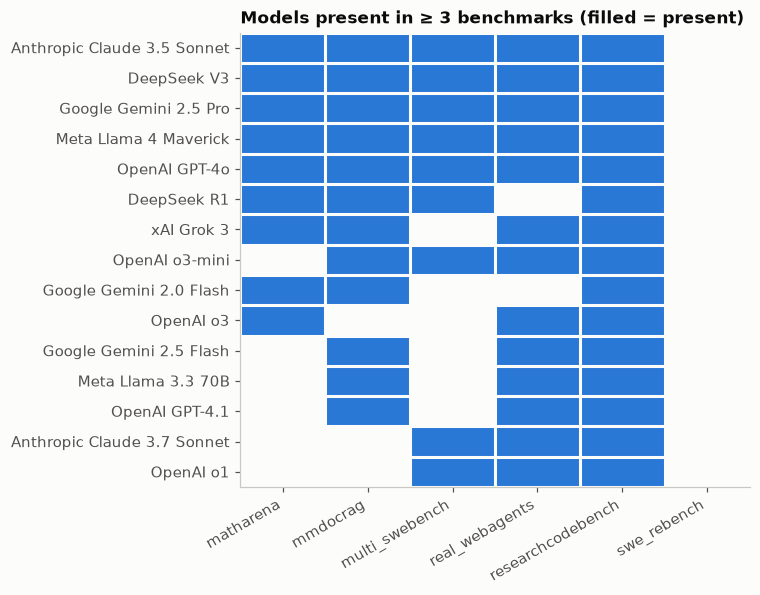

In [8]:
subj_all = pd.concat([load(b, "subjects").assign(benchmark=b) for b in BENCHMARKS], ignore_index=True)
print(f"{len(subj_all)} subject rows · normalized_name filled: {subj_all.normalized_name.notna().mean():.0%}")
presence = (subj_all.dropna(subset=["normalized_name"])
            .groupby(["normalized_name", "benchmark"]).size().unstack(fill_value=0).gt(0).astype(int))
n_bench = presence.sum(axis=1)
print("models by number of benchmarks they appear in:", n_bench.value_counts().sort_index().to_dict())

shared = presence[n_bench >= 3].assign(n=n_bench).sort_values(["n"] + BENCHMARKS, ascending=False).drop(columns="n")
fig, ax = plt.subplots(figsize=(7, 0.3 * len(shared) + 1))
ax.imshow(np.ma.masked_equal(shared.values, 0), cmap=LinearSegmentedColormap.from_list("one", [BLUE, BLUE]),
          aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(shared.columns)), shared.columns, rotation=30, ha="right")
ax.set_yticks(range(len(shared)), shared.index)
ax.set_xticks(np.arange(-0.5, len(shared.columns)), minor=True)
ax.set_yticks(np.arange(-0.5, len(shared)), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
ax.set_title("Models present in ≥ 3 benchmarks (filled = present)")
fig.tight_layout()
plt.show()

So model selection is very varied and includes both open-source and closed-source models. 

---
## 2. MathArena

- Mostly text, only 20% of items need images. 
- Mix of agentic and non-agentic (multi-turn & single-turn).
- Lots of missing values on the subjets data that will need to be handled (provider, reasoning effort). 
- No missing item data
- Evaluation: mix of exact matcher and judge.

In [9]:
B = "matharena"

### 2.1 benchmarks

In [10]:
eda_benchmarks(B)

**MathArena** — Measures mathematical problem solving through final-answer correctness and criterion-level proof grades.

MathArena scores models on problems from recent mathematics competitions, checking the final answer where there is one
and having judges grade written proofs criterion by criterion where the problem asks for a proof. 



,value
benchmark_id,matharena
name,MathArena
version,NaN
license,CC-BY-NC-SA-4.0 AND CC-BY-SA-4.0
source_url,https://github.com/eth-sri/matharena
modality,"[text, image]"
domain,[mathematics]
multi_single_turn,"multi_turn, single_turn"
response_type,mixed
response_scale,"{""kind"":""mixed""}"


### 2.2 subjects

104 subjects · subject_id unique: True · distinct normalized_name: 45


,dtype,non_null,non_null_%,n_unique,example
subject_id,str,104,100.0,104,8413d1f86426bfa2
display_name,str,104,100.0,104,Kimi K2 Thinking
normalized_name,str,52,50.0,45,Moonshot Kimi K2
provider,str,52,50.0,14,Moonshot
release_date,str,52,50.0,39,2025-07-11
access_date,str,0,0.0,0,
harness,str,0,0.0,0,
reasoning_effort,str,31,29.8,5,high
harness_version,str,0,0.0,0,
subject_features_extra,str,104,100.0,104,model_config=moonshot/k2-thinking;source_model_name=Kimi K2…


subject_features_extra keys: {'model_config': 102, 'source_model_name': 104}


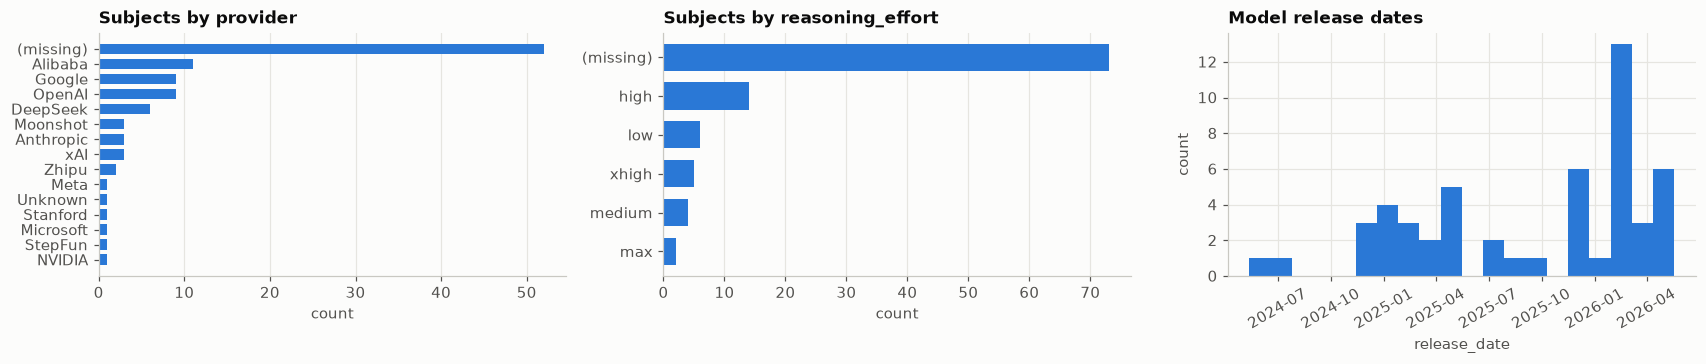

,subject_id,display_name,normalized_name,provider,release_date,access_date,harness,reasoning_effort,harness_version
0,8413d1f86426bfa2,Kimi K2 Thinking,Moonshot Kimi K2,Moonshot,2025-07-11,NaN,NaN,NaN,NaN
1,64ef8c71d54e3a1b,Kimi K2.5 (Think),Moonshot Kimi K2.5,Moonshot,2026-01-27,NaN,NaN,NaN,NaN
2,68c86aed89037bce,Claude-Opus-4.0 (Think),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,b9d0ce1d510c35cd,Claude-3.7-Sonnet (Think),NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6778df072cd56c20,Claude-Sonnet-4.5 (Think),NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ab0a3696644f965d,Claude-3.5-Sonnet,Anthropic Claude 3.5 Sonnet,Anthropic,2024-06-20,NaN,NaN,NaN,NaN
6,dfff9b0c51c0e9fd,DeepSeek-v3.2-Speciale,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,fb0cf3145b3b6207,DeepSeek-R1-Distill-14B,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
subjects = eda_subjects(B)

So:
- NOT AGENTIC, as no harness used.
- For most models, no reasoning effort reported, however the name and rasoning length can give some hints. 
- Also provider is missing

In general, **lots of missing values that need to be resolve!!!**.

### 2.3 items

1,755 items · item_id unique: True · raw_item_id unique: False · duplicate content_hash: 858


,dtype,non_null,non_null_%,n_unique,example
item_id,str,1755,100.0,1755,25fe37ba23449698
benchmark_id,str,1755,100.0,1,matharena
raw_item_id,str,1755,100.0,680,aime_2025::2
content,str,1755,100.0,898,"Please reason step by step, and put your final answer withi…"
asset_manifest,str,336,19.1,168,"[{""asset_id"":""df87fa0c2ae3da1ae548f544e737aaea9a3c55e61a3b3…"
grading_criterion,str,1755,100.0,459,"{""reference_answer"":""588"",""response_scale"":{""kind"":""discret…"
verifier,str,1755,100.0,514,"{""class"": ""exact_matcher"", ""reference_answer_sha256"": ""0932…"
content_hash,str,1755,100.0,897,20f840bec08cede6
item_features,str,1755,100.0,848,competition=aime_2025;problem_idx=2;prompt_source=user_mess…


grading_criterion keys: {'reference_answer': 1755, 'response_scale': 1755, 'rule': 1755}
verifier keys: {'class': 1755, 'spec': 1755, 'reference_answer_sha256': 1484, 'criterion_index': 271, 'judge': 271, 'judge_slot': 271, 'judged_by': 271, 'rubric_sha256': 271}
grading rules: {"The provider's parsed final answer matches gold_answer.": 1484, '{"grading_scheme_desc": "Credit given by the graders from the Putnam Competition.", "max_…': 24, '{"grading_scheme_desc": "Is the solution correct?", "max_points": 1, "title": "Correctnes…': 13, '{"grading_scheme_desc": "1 point should be given for just finding the answer $k=0,1,3$", …': 5}


,n_unique,non_null,top_values
item_features key,,,
competition,27,1755,"{'cmimc_2025': 209, 'smt_2025': 168, 'aime_2025': 155, 'imo_2025': 141}"
problem_idx,53,1755,"{'1': 101, '5': 92, '3': 89, '2': 88}"
prompt_source,1,1755,{'user_message': 1755}
image_detail,2,336,"{'[null]': 168, '[""high""]': 168}"


verifier class: {'exact_matcher': 1484, 'judge': 271}


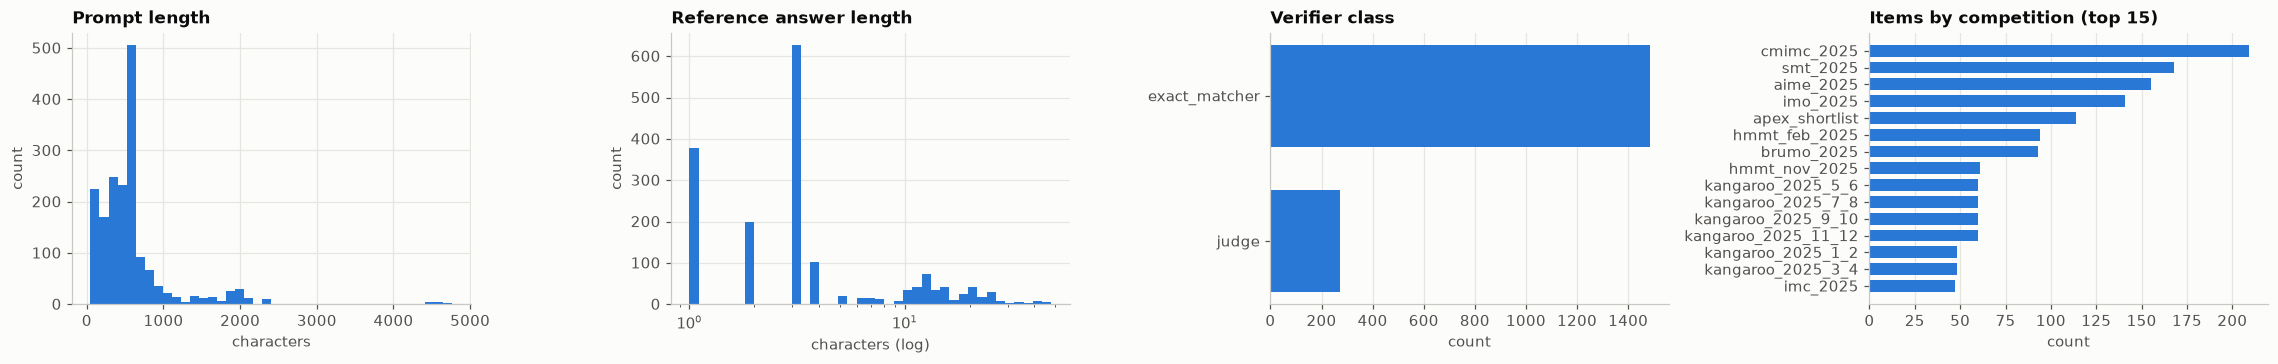

--- example item aime_2025::2 ---
Please reason step by step, and put your final answer within \boxed{}. The answer is an integer between 0 and 999 inclusive. On $\triangle ABC$ points $A, D, E$, and $B$ lie in that order on side $\overline{AB}$ with $AD = 4$, $DE = 16$, $EB = 8$. Points $A, F, G$ and $C$ lie in that order on side $\overline{AC}$ with $AF = 13$, $FG = 52$, and $GC = 26$. Let $M$ be the reflection of $D$ through $F$, and let $N$ be the reflection of $G$ through $E$. Quadrilateral $DEGF$ has area $288$. Find the area of heptagon $AFNBCEM$. \begin{tikzpicture}[scale=0.07, line join=round, line cap=round, >=stealth] \coordinate (A) at (100,100); \coordinate (D) at (95,80); \coordinate (F) at (130,80); …
reference answer: 588
verifier: {"class": "exact_matcher", "reference_answer_sha256": "09325e1d9dff5fd9386a2d3c6b8f13cbac0a5bce719933c984650f416027286e", "spec": "Import the provider's released correct boolean as 0 or 1; the provider compares its parsed final answer with go

In [12]:
items = eda_items(B)

### 2.4 response

92,944 responses · 104 subjects × 1,755 items · trials 1–200 · response_id unique: True
missing scores: 0 · duplicate (subject, item, trial, condition): 0
test_condition: {nan: 92944}
interactors: {nan: 92944}
orphans — subjects not in subjects table: 0, items not in items table: 0
subject × item matrix: 104 × 1,755, 11.2% of cells observed


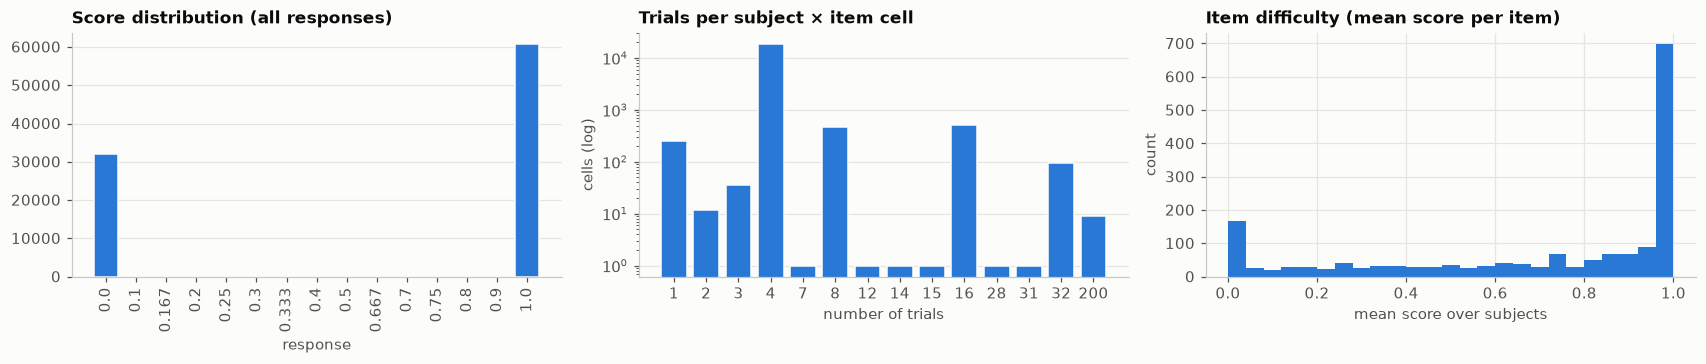

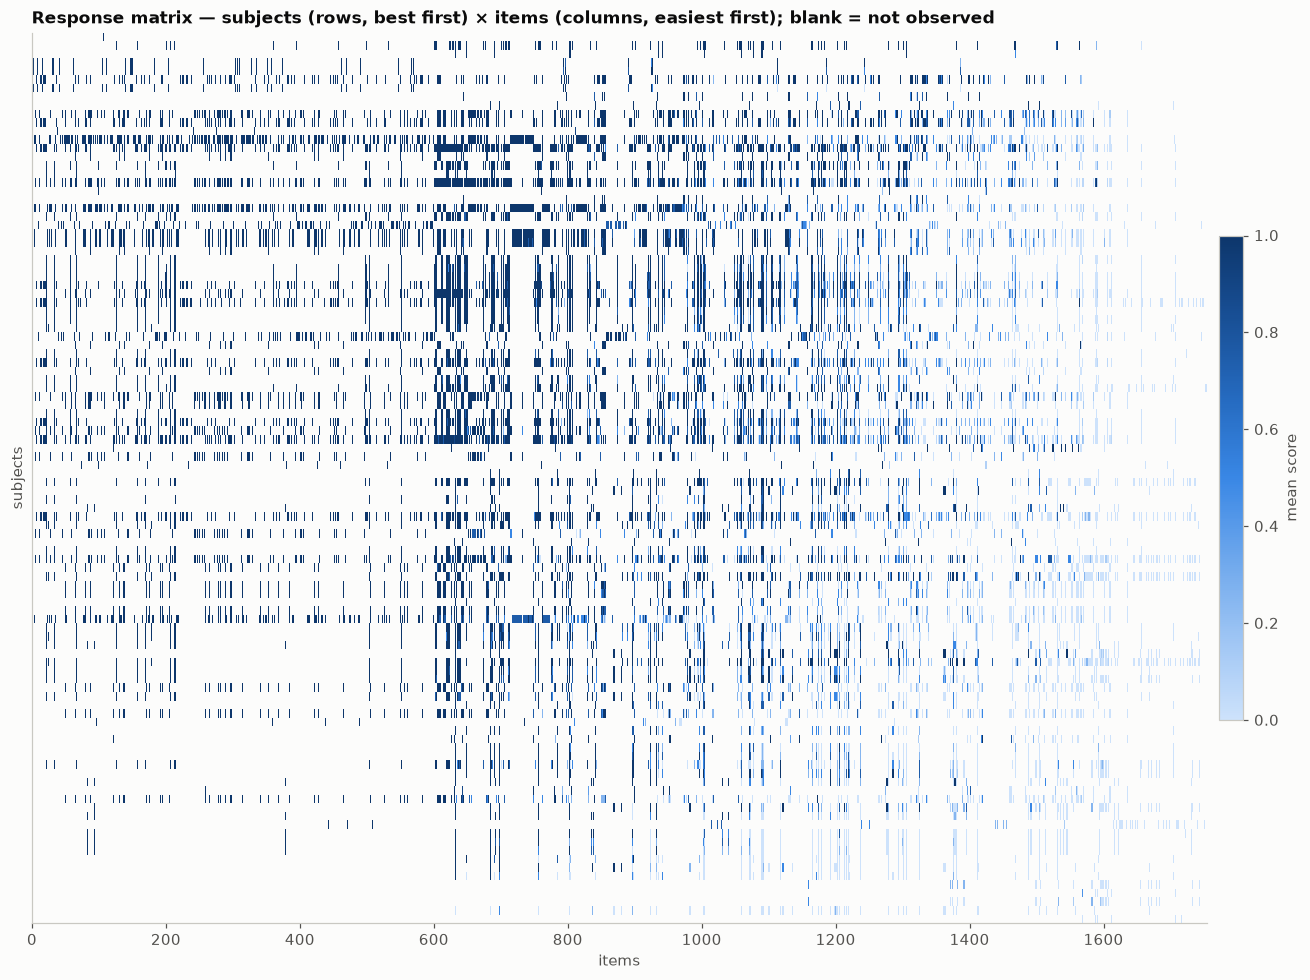

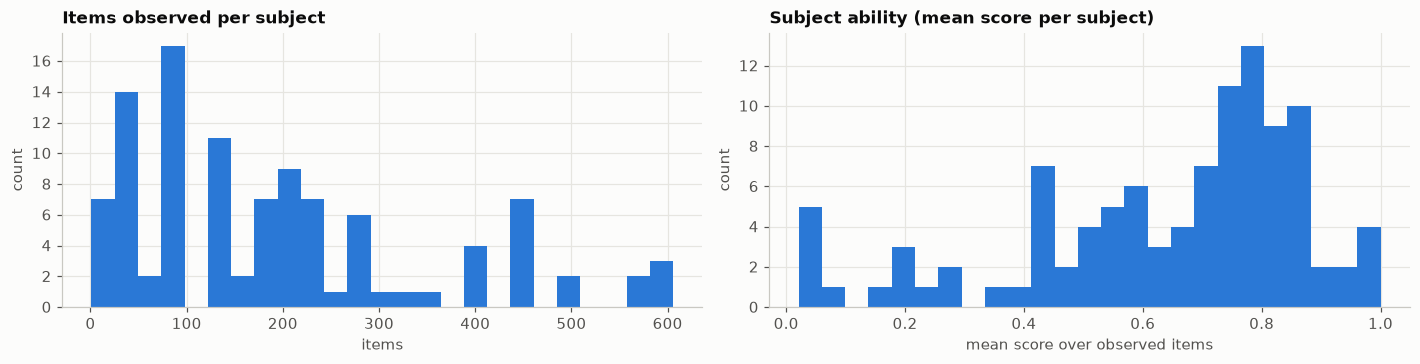

Subjects by mean score (top 10 / bottom 10), excluding 5 subjects with < 20 observed items. Raw means are not comparable when subjects saw different items:


,subject,mean_score,n_items
0,GPT-5.2 (xhigh),0.986,142
1,GLM 4.7,0.972,30
2,Gemini 2.5 Pro (agent),0.968,47
3,Gemini IMO Deep Think,0.953,47
4,GPT-5.5 (xhigh),0.948,291
5,Gemini 2.5 Pro (best-of-32),0.889,47
6,DeepSeek-v4-Flash (Max),0.885,48
7,gemini-2.5-pro*,0.875,30
8,Gemini 3.1 Pro Preview,0.863,393
9,GPT-5.4 (xhigh),0.861,393


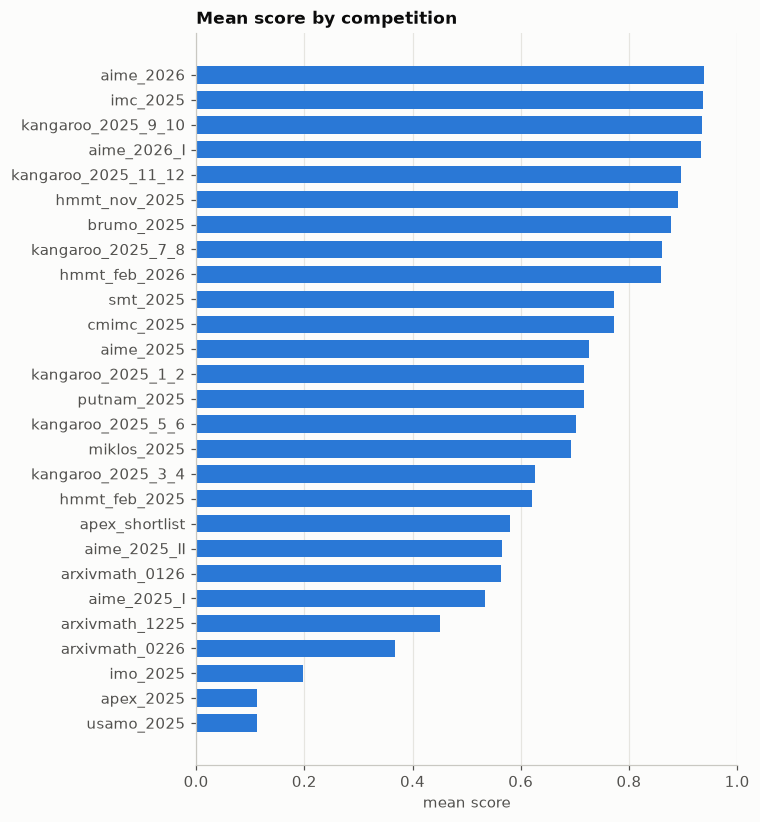

In [13]:
responses = eda_responses(B)

,items,subjects,responses,mean_score,verifier
competition,,,,,
usamo_2025,46,10,1680,0.112,judge
apex_2025,25,41,7245,0.113,exact_matcher
imo_2025,141,7,1556,0.198,judge
arxivmath_0226,32,17,2135,0.367,exact_matcher
arxivmath_1225,17,21,2832,0.451,exact_matcher
aime_2025_I,46,31,1860,0.533,exact_matcher
arxivmath_0126,23,23,3279,0.563,exact_matcher
aime_2025_II,16,31,1860,0.565,exact_matcher
apex_shortlist,114,35,9237,0.581,exact_matcher


score values by verifier:


,count,mean,std,min,25%,50%,75%,max
verifier,,,,,,,,
exact_matcher,89482.0,0.671,0.470,0.0,0.0,1.0,1.0,1.0
judge,3462.0,0.199,0.394,0.0,0.0,0.0,0.0,1.0


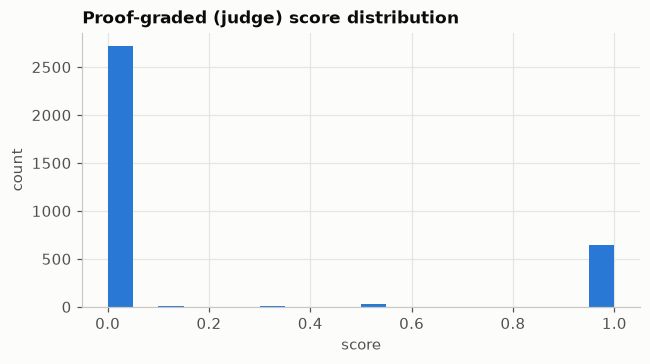

In [ ]:
# Competitions and grading type

feats = kv_frame(items.item_features)
item_meta = pd.DataFrame({
    "item_id": items.item_id,
    "competition": feats.competition,
    "verifier": items.verifier.map(lambda v: parse_json(v)["class"]),
})
rm = responses.merge(item_meta, on="item_id")
comp = rm.groupby("competition").agg(
    items=("item_id", "nunique"), subjects=("subject_id", "nunique"), responses=("response", "size"),
    mean_score=("response", "mean"), verifier=("verifier", lambda v: "/".join(sorted(v.unique()))),
).sort_values("mean_score")
display(comp.round(3))
print("score values by verifier:")
display(rm.groupby("verifier").response.describe().round(3))

fig, axes = panels(1, width=6)
hist(axes[0], rm.loc[rm.verifier == "judge", "response"], "Proof-graded (judge) score distribution", "score", bins=20)
fig.tight_layout()
plt.show()

### 2.5 traces

90,005 traces · covers 96.8% of responses · orphan traces (no response): 0
null/empty traces: 0 / 0


,count,mean,std,min,5%,50%,95%,max
chars,90005.0,7514.6,24413.4,2.0,20.0,1759.0,43211.6,613083.0
lines,90005.0,153.3,483.2,1.0,2.0,33.0,867.0,34507.0
files_in_diff,90005.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


traces that are git diffs: 0.0%


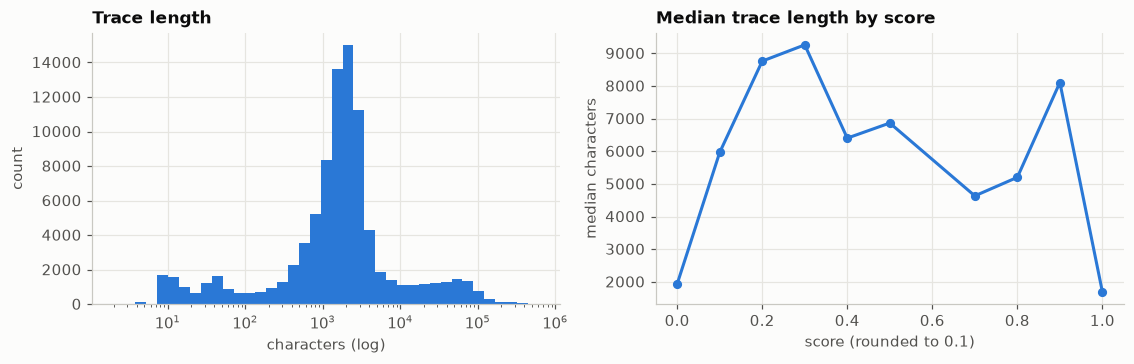

Spearman correlation(trace length, score): -0.044

--- random trace 1 (1,629 chars) ---
The problem asks for the exact correlation coefficient of the asymptotic bivariate normal distribution of the number of hairpins ($H_n$) and the number of basepairs ($B_n$) in a random RNA secondary structure of length $n$ under the uniform probability model. This problem is addressed in the literature on the combinatorial analysis of RNA secondary structures. Specifically, the paper "On the number of base pairs and loops in RNA secondary structures" by J. Schmitt (2004) derives the asymptotic distribution of these parameters. In this work, Schmitt establishes that $H_n$ and $B_n$ are …

--- random trace 2 (3,117 chars) ---
The minimum possible value of \(N\) is 2, achieved when there are exactly two chords, both of length 2025. Consider a continuous function \(f: \mathbb{R} \to \mathbb{R}\) defined as follows. Set \(a = 0\) for simplicity, so the chord of length 2025 is at \(x = 0\) and \(x = 2025\

In [15]:
traces = eda_traces(B, responses)

### 2.6 assets

168 assets · 15.9 MB · asset_id unique: True · byte_size matches payload: True
items with assets: 336 · manifest entries: 336 · entries pointing to a missing asset: 0 · assets referenced by no item: 0
media_type: {'image/png': 336} · role: {'input_image': 336}
assets per item: {1: 336} · distinct items (raw_item_id) with images: 168


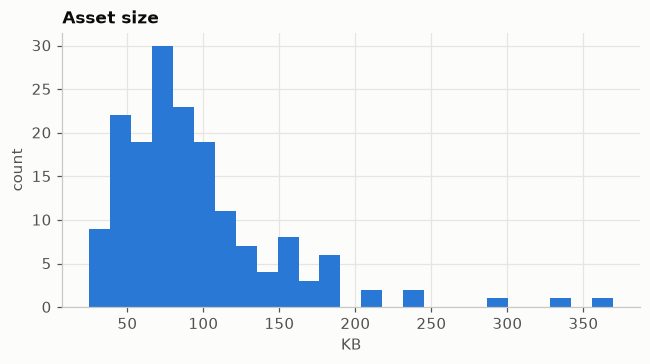

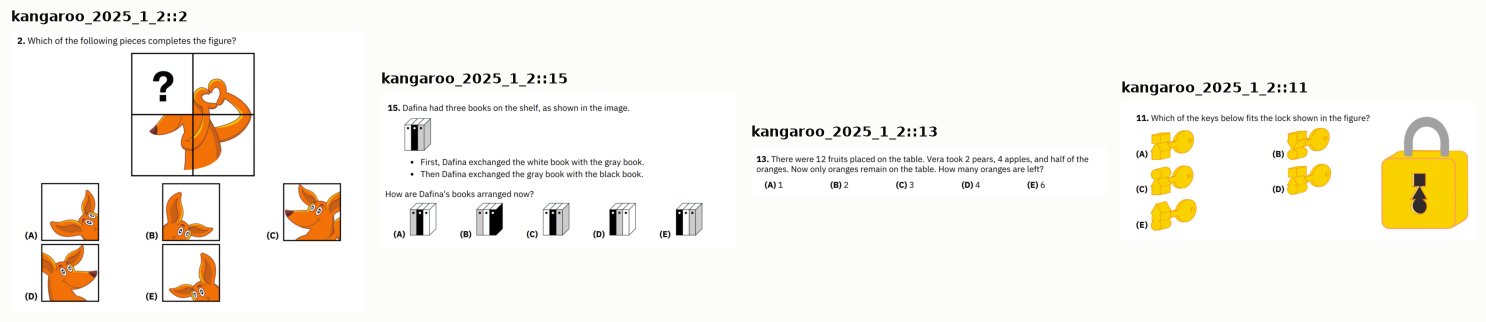

In [16]:
assets = eda_assets(B)

---
## 3. MMDocRAG

- Non agentic
- Subject data really complete
- All items contain images
- Evaluation: Judge
- Evaluate both multimodal and text-only models. 

In [17]:
B = "mmdocrag"

### 3.1 benchmarks

In [18]:
eda_benchmarks(B)

**MMDocRAG** — nan

MMDocRAG tests whether models can answer questions about documents by weaving retrieved text and images into a cited
answer, which a judge model rates for fluency, citation quality, coherence, reasoning and factuality. 



,value
benchmark_id,mmdocrag
name,MMDocRAG
version,NaN
license,CC-BY-NC-4.0
source_url,https://github.com/MMDocRAG/MMDocRAG
modality,"[image, text]"
domain,"[general, reasoning]"
multi_single_turn,single_turn
response_type,fraction
response_scale,"{""kind"":""discrete"",""values"":[0.0,0.04,0.08,0.12,0.16,0.2,0.24,0.28,0.32,0.36..."


### 3.2 subjects

68 subjects · subject_id unique: True · distinct normalized_name: 64


,dtype,non_null,non_null_%,n_unique,example
subject_id,str,68,100.0,68,e57466a395ae6879
display_name,str,68,100.0,68,internvl3-38b
normalized_name,str,68,100.0,64,OpenGVLab InternVL3 38B
provider,str,68,100.0,11,OpenGVLab
release_date,str,68,100.0,37,2025-04-11
access_date,str,0,0.0,0,
harness,str,0,0.0,0,
reasoning_effort,str,0,0.0,0,
harness_version,str,0,0.0,0,
subject_features_extra,str,5,7.4,1,released_variant=no-think


subject_features_extra keys: {'released_variant': 1}


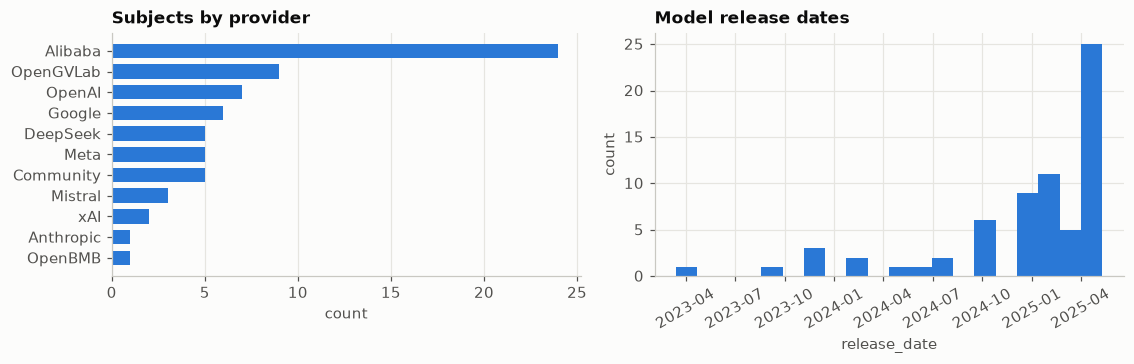

,subject_id,display_name,normalized_name,provider,release_date,access_date,harness,reasoning_effort,harness_version
0,e57466a395ae6879,internvl3-38b,OpenGVLab InternVL3 38B,OpenGVLab,2025-04-11,NaN,NaN,NaN,NaN
1,6132a6d2f00daf1a,internvl3-78b,OpenGVLab InternVL3 78B,OpenGVLab,2025-04-11,NaN,NaN,NaN,NaN
2,c68b0b4cebac1009,claude-3.5-sonnet,Anthropic Claude 3.5 Sonnet,Anthropic,2024-06-20,NaN,NaN,NaN,NaN
3,a3e762a25636977b,deepseek-r1-distill-llama-70b,DeepSeek R1 Distill Llama 70B,DeepSeek,2025-01-20,NaN,NaN,NaN,NaN
4,66c4ad8d059f92bb,deepseek-r1-distill-qwen-32b,DeepSeek R1 Distill Qwen 32B,DeepSeek,2025-01-20,NaN,NaN,NaN,NaN
5,50cbacf8db8037c0,deepseek-r1,DeepSeek R1,DeepSeek,2025-01-20,NaN,NaN,NaN,NaN
6,7bc3eed814b23142,deepseek-v3,DeepSeek V3,DeepSeek,2024-12-26,NaN,NaN,NaN,NaN
7,563f181242d45ea1,gemini-1.5-pro,Google Gemini 1.5 Pro,Google,2024-02-15,NaN,NaN,NaN,NaN


In [19]:
subjects = eda_subjects(B)

### 3.3 items

2,000 items · item_id unique: True · raw_item_id unique: True · duplicate content_hash: 0


,dtype,non_null,non_null_%,n_unique,example
item_id,str,2000,100.0,2000,08b209168a6a4f97
benchmark_id,str,2000,100.0,1,mmdocrag
raw_item_id,str,2000,100.0,2000,q_id::1
content,str,2000,100.0,2000,"Among the Higher-income seniors, what are the percentage of…"
asset_manifest,str,0,0.0,0,
grading_criterion,str,2000,100.0,1905,"{""reference_answer"":""['90%', '42%', '39%']"",""rule"":""Mean of…"
verifier,str,2000,100.0,1,"{""class"": ""judge"", ""judged_by"": ""llm"", ""spec"": ""Provider MM…"
content_hash,str,2000,100.0,2000,dfb7551fa0c0c90f
item_features,str,0,0.0,0,


grading_criterion keys: {'reference_answer': 2000, 'rule': 2000}
verifier keys: {'class': 2000, 'judged_by': 2000, 'spec': 2000}
grading rules: {'Mean of the five 0-5 scores for Fluency, Citation Quality, Text-Image Coherence, Reasonin…': 2000}
verifier class: {'judge': 2000}


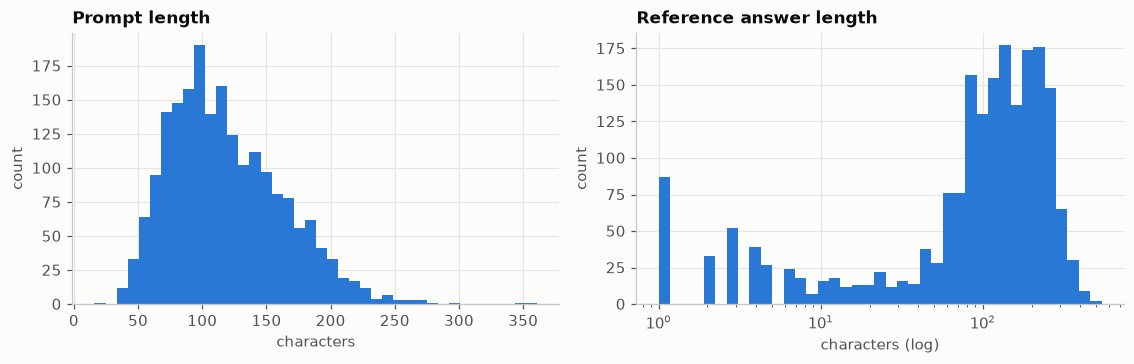

--- example item q_id::1 ---
Among the Higher-income seniors, what are the percentage of them go online, has smartphone phone, and own a tablet computer? Please write the answer in the list format and in descend order,e.g., ["9%","8%"] in the Pew Research Center’s Internet Project July 18-September 30, 2013 tracking survey?
reference answer: ['90%', '42%', '39%']
verifier: {"class": "judge", "judged_by": "llm", "spec": "Provider MMDocRAG evaluation using prompt_bank/evaluation_answer.txt; exact judge configuration is not attributed per released cell. Preserve the released dimension grades without rejudging."}


In [20]:
items = eda_items(B)

### 3.4 response

342,695 responses · 68 subjects × 2,000 items · trials 1–1 · response_id unique: True


missing scores: 129 · duplicate (subject, item, trial, condition): 0
test_condition: {'pure-text/quotes15': 108458, 'pure-text/quotes20': 108308, 'multimodal/quotes20': 63963, 'multimodal/quotes15': 61966}
interactors: {nan: 342695}
orphans — subjects not in subjects table: 0, items not in items table: 0
subject × item matrix: 68 × 2,000, 98.9% of cells observed
every cell has exactly 1 trial(s)


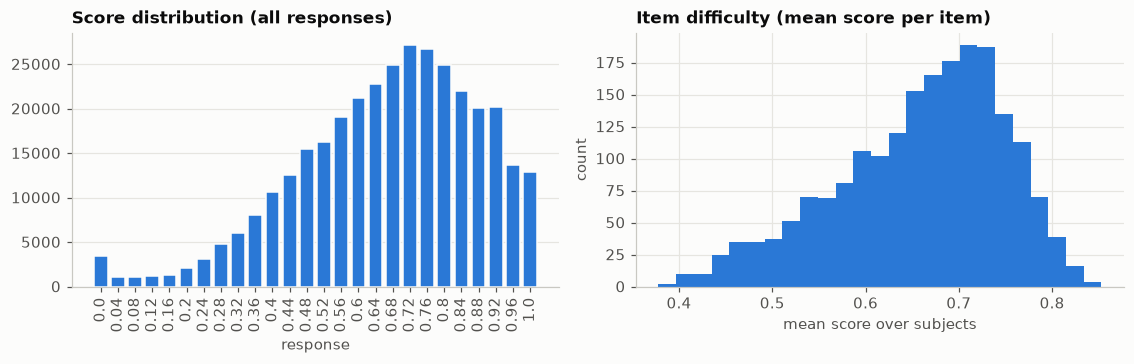

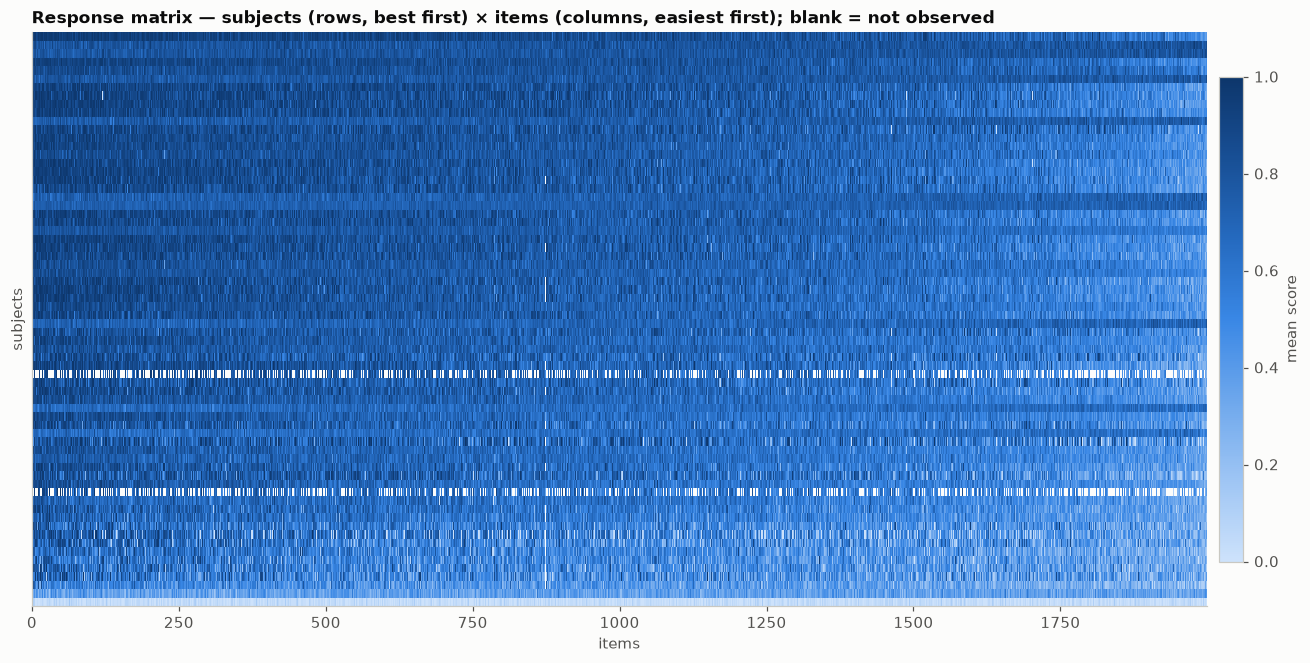

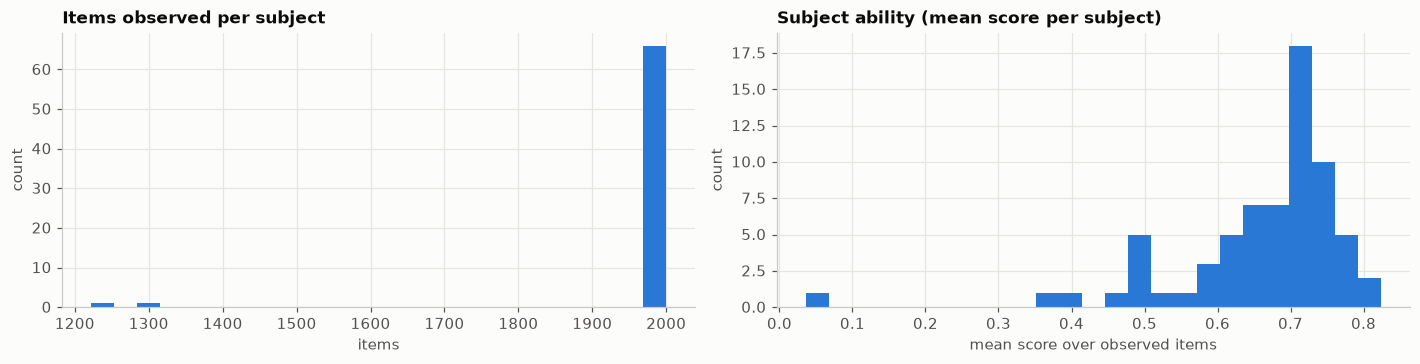

Subjects by mean score (top 10 / bottom 10). Raw means are not comparable when subjects saw different items:


,subject,mean_score,n_items
0,gpt-4.1,0.824,2000
1,qwen2.5-72b-ft,0.794,2000
2,qwen2.5-32b-ft,0.788,2000
3,gpt-4.1-mini,0.785,2000
4,gemini-2.5-pro,0.774,2000
5,qwen2.5-14b-ft,0.774,2000
6,grok-3-beta,0.768,2000
7,qwen-max,0.754,2000
8,qwen3-235b-a22b,0.753,2000
9,qwen2.5-72b,0.751,2000


In [21]:
responses = eda_responses(B)

,subjects,items,responses,mean_score
test_condition,,,,
multimodal/quotes15,31,2000,61966,0.635
multimodal/quotes20,32,2000,63963,0.622
pure-text/quotes15,55,2000,108458,0.693
pure-text/quotes20,55,2000,108308,0.689


pure-text/quotes20 − pure-text/quotes15: mean -0.004 over 55 subjects
multimodal/quotes20 − pure-text/quotes20: mean -0.011 over 19 subjects


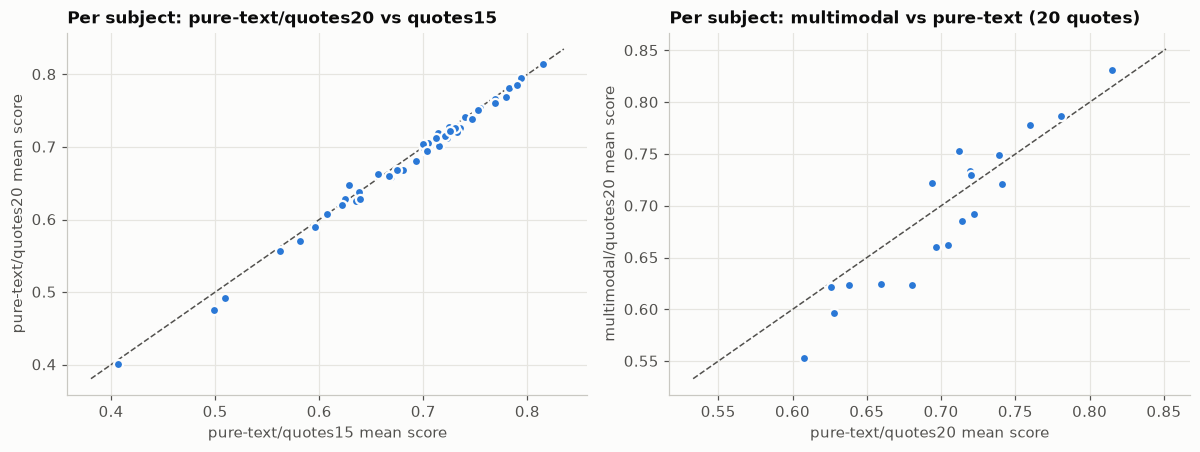

In [ ]:
# Test conditions
labels = subject_labels(subjects)
cond = responses.groupby("test_condition").agg(
    subjects=("subject_id", "nunique"), items=("item_id", "nunique"),
    responses=("response", "size"), mean_score=("response", "mean"),
)
display(cond.round(3))

per_subj = responses.groupby(["subject_id", "test_condition"]).response.mean().unstack()
fig, axes = panels(2, width=5.5, height=4.2)
for ax, (x, y) in zip(axes, [("pure-text/quotes15", "pure-text/quotes20"), ("pure-text/quotes20", "multimodal/quotes20")]):
    pair = per_subj[[x, y]].dropna()
    ax.scatter(pair[x], pair[y], s=36, color=BLUE, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    lo, hi = pair.min().min() - 0.02, pair.max().max() + 0.02
    ax.plot([lo, hi], [lo, hi], color=INK2, linewidth=1, linestyle="--", zorder=2)
    ax.set_xlabel(f"{x} mean score")
    ax.set_ylabel(f"{y} mean score")
    ax.set_title(f"Per subject: {y.split('/')[0]}/{y.split('/')[1]} vs {x.split('/')[1]}" if x.split('/')[0] == y.split('/')[0]
                 else "Per subject: multimodal vs pure-text (20 quotes)")
    print(f"{y} − {x}: mean {(pair[y] - pair[x]).mean():+.3f} over {len(pair)} subjects")
fig.tight_layout()
plt.show()

### 3.5 traces

328,286 traces · covers 95.8% of responses · orphan traces (no response): 0
null/empty traces: 0 / 0


,count,mean,std,min,5%,50%,95%,max
chars,328286.0,1886.3,2126.7,1.0,391.0,1562.0,4472.0,302713.0
lines,328286.0,19.6,327.0,1.0,1.0,12.0,42.0,89381.0
files_in_diff,328286.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


traces that are git diffs: 0.0%


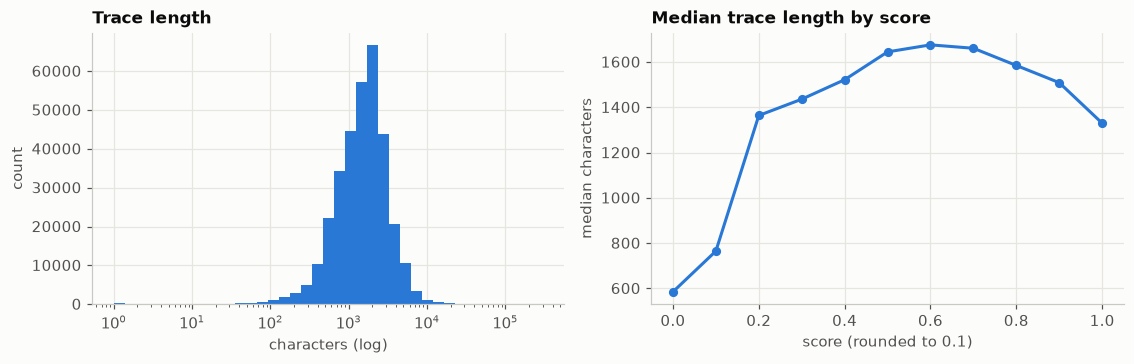

Spearman correlation(trace length, score): +0.014

--- random trace 1 (866 chars) ---
Based on the provided text and image quotes, we can extract the following information: - For the general public, the percentage of those believing the government was doing very/fairly well in reducing the threat of terrorism had fallen to 46% by 2015, down from 72% in January of that year [6, 10]. - Among Republicans, the percentage who believed the government was doing very/fairly well in reducing the threat of terrorism had dropped significantly from 63% at the beginning of the year to 27% by December 2015 [9, 10]. - Among Democrats, the percentage who believed the government was doing …

--- random trace 2 (926 chars) ---
**Interleaved Response:** Based on the provided information, we can find the optimal `α` values for achieving the highest scores on the Chinese Onto4.0 and English QuoRef datasets from `image5`. First, let's consider the Chinese Onto4.0 dataset: - For `α = 0.2`, the score is `81.1

In [23]:
traces = eda_traces(B, responses)

---
## 4. Multi-SWE-bench

- Text only and agentic.
- Low coverage
- Minor missing data on subjects.
- Some models are runned on several harnesses. 

In [25]:
B = "multi_swebench"

### 4.1 benchmarks

In [26]:
eda_benchmarks(B)

**Multi-SWE-bench** — nan

Multi-SWE-bench tests whether coding agents can resolve real issues in open source repositories written in languages
beyond Python, such as Java, Go and Rust, counting an issue resolved only when the agent's patch passes the project's
tests. 



,value
benchmark_id,multi_swebench
name,Multi-SWE-bench
version,NaN
license,Apache-2.0
source_url,https://github.com/multi-swe-bench/experiments
modality,[text]
domain,"[software_engineering, agents_and_tool_use]"
multi_single_turn,multi_turn
response_type,binary
response_scale,"{""direction"":""higher_is_better"",""kind"":""discrete"",""meanings"":{""0"":""failure"",..."


### 4.2 subjects

82 subjects · subject_id unique: True · distinct normalized_name: 20


,dtype,non_null,non_null_%,n_unique,example
subject_id,str,82,100.0,82,44445017f07cd5bb
display_name,str,82,100.0,20,Claude-3.5-Sonnet(Oct)
normalized_name,str,82,100.0,20,Anthropic Claude 3.5 Sonnet
provider,str,82,100.0,10,Anthropic
release_date,str,80,97.6,18,2024-06-20
access_date,str,82,100.0,11,2025-03-29
harness,str,81,98.8,11,MSWE-agent
reasoning_effort,str,0,0.0,0,
harness_version,str,0,0.0,0,
subject_features_extra,str,0,0.0,0,


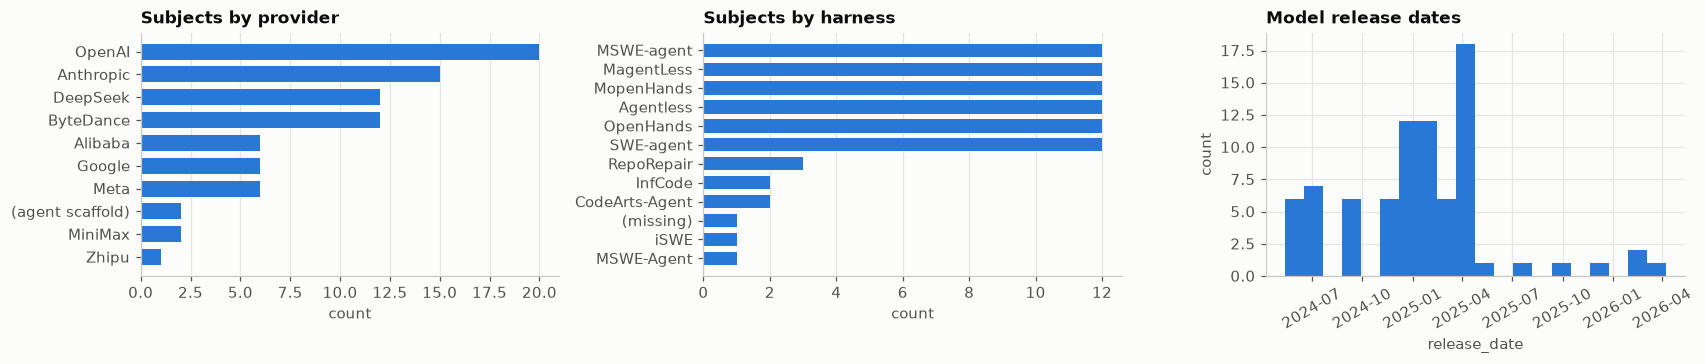

,subject_id,display_name,normalized_name,provider,release_date,access_date,harness,reasoning_effort,harness_version
0,44445017f07cd5bb,Claude-3.5-Sonnet(Oct),Anthropic Claude 3.5 Sonnet,Anthropic,2024-06-20,2025-03-29,MSWE-agent,NaN,NaN
1,3f2906bbb64dc1a7,Claude-3.7-Sonnet,Anthropic Claude 3.7 Sonnet,Anthropic,2025-02-24,2025-03-29,MSWE-agent,NaN,NaN
2,0060b6030d4c2297,DeepSeek-R1,DeepSeek R1,DeepSeek,2025-01-20,2025-03-29,MSWE-agent,NaN,NaN
3,d79b3584f7cdf43e,DeepSeek-V3,DeepSeek V3,DeepSeek,2024-12-26,2025-03-29,MSWE-agent,NaN,NaN
4,615494f08b332496,Doubao-1.5-pro,ByteDance Doubao 1.5 Pro,ByteDance,2025-01-22,2025-03-29,MSWE-agent,NaN,NaN
5,3cd24d59a3eb8d36,GPT-4o-1120,OpenAI GPT-4o,OpenAI,2024-05-13,2025-03-29,MSWE-agent,NaN,NaN
6,8f6d5a5c51a8db9d,OpenAI-o1,OpenAI o1,OpenAI,2024-12-05,2025-03-29,MSWE-agent,NaN,NaN
7,370de70a197c04ad,OpenAI-o3-mini-high,OpenAI o3-mini,OpenAI,2024-12-20,2025-03-29,MSWE-agent,NaN,NaN


In [27]:
subjects = eda_subjects(B)

### 4.3 items

2,126 items · item_id unique: True · raw_item_id unique: True · duplicate content_hash: 48


,dtype,non_null,non_null_%,n_unique,example
item_id,str,2126,100.0,2126,2e95f86eb424711f
benchmark_id,str,2126,100.0,1,multi_swebench
raw_item_id,str,2126,100.0,2126,catchorg__Catch2-1422
content,str,2126,100.0,2078,unregistered reporter is not considered a command line erro…
asset_manifest,str,0,0.0,0,
grading_criterion,str,2126,100.0,2116,"{""reference_answer"":""diff --git a/include/internal/catch_co…"
verifier,str,2126,100.0,2121,"{""class"": ""exact_matcher"", ""spec"": ""{\""test_patch\"": \""diff…"
content_hash,str,2126,100.0,2078,ab3543cf45955a1b
item_features,str,2126,100.0,8,lang=c++


grading_criterion keys: {'reference_answer': 2126, 'rule': 2126}
verifier keys: {'class': 2126, 'spec': 2126}
grading rules: {'The patch must pass the released FAIL_TO_PASS tests and preserve PASS_TO_PASS tests.': 2126}


,n_unique,non_null,top_values
item_features key,,,
lang,8,2126,"{'python': 500, 'go': 428, 'javascript': 356, 'rust': 239}"


verifier class: {'exact_matcher': 2126}


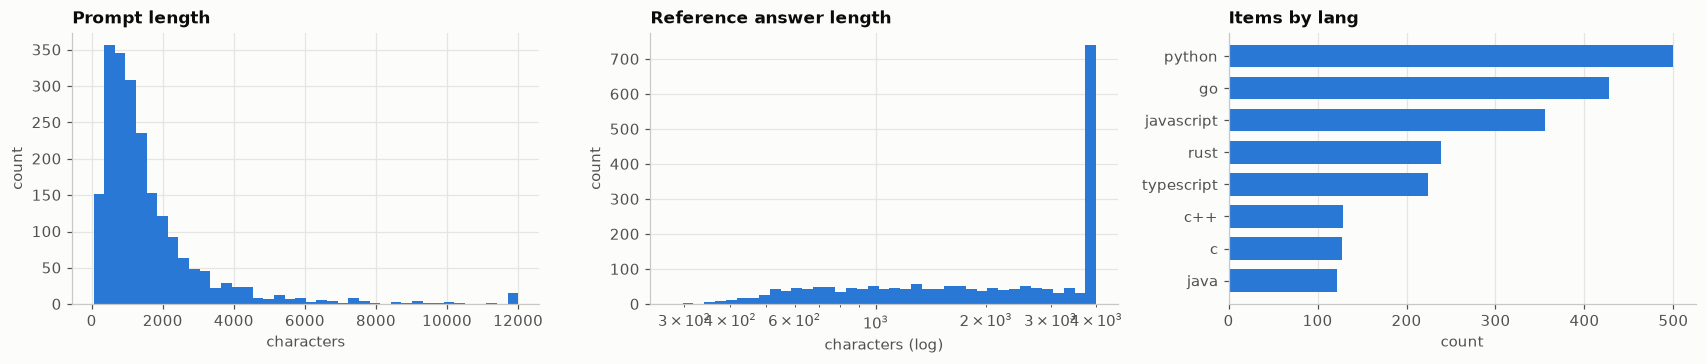

--- example item catchorg__Catch2-1422 ---
unregistered reporter is not considered a command line error ## Description when `session.applyCommandLine()` is called with an unregistered reporter, the function simply returns 0 and the later call to `session.run()` just outputs a text: `No reporter registered with name: 'foo'` ### Steps to reproduce int main() { const char* argv[] = { "runner", "-r foo" }; Catch::Session session; const int command_line_errors = session.applyCommandLine( std::size( argv ), const_cast< char** >( argv ) ); if ( command_line_errors == 0 ) { session.run(); } else { Catch::cerr() << "Error parsing following command line: " << *std::prev( std::end( argv ) ) << std::endl; } } I would expect the parser to …
reference answer: diff --git a/include/internal/catch_commandline.cpp b/include/internal/catch_commandline.cpp ⏎ index c57b7ed74d..66759ebbf1 100644 ⏎ --- a/include/internal/catch_commandline.cpp ⏎ +++ b/include/internal/catch_commandline.cpp ⏎ @@ -10,6 +10,9 @@

In [28]:
items = eda_items(B)

### 4.4 response

57,975 responses · 82 subjects × 2,126 items · trials 1–2 · response_id unique: True
missing scores: 0 · duplicate (subject, item, trial, condition): 0
test_condition: {nan: 57975}
interactors: {nan: 57975}


orphans — subjects not in subjects table: 0, items not in items table: 0
subject × item matrix: 82 × 2,126, 33.2% of cells observed


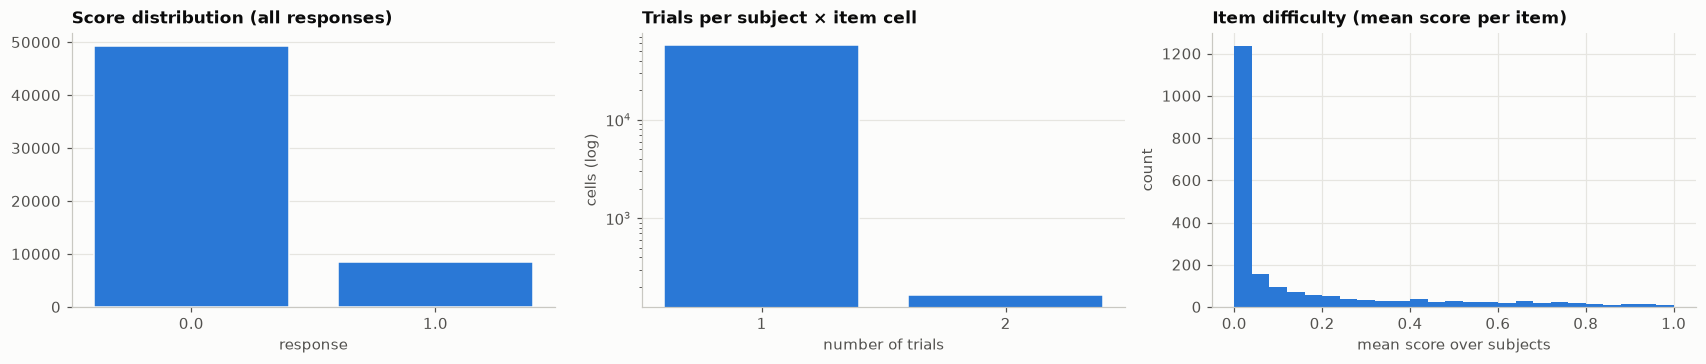

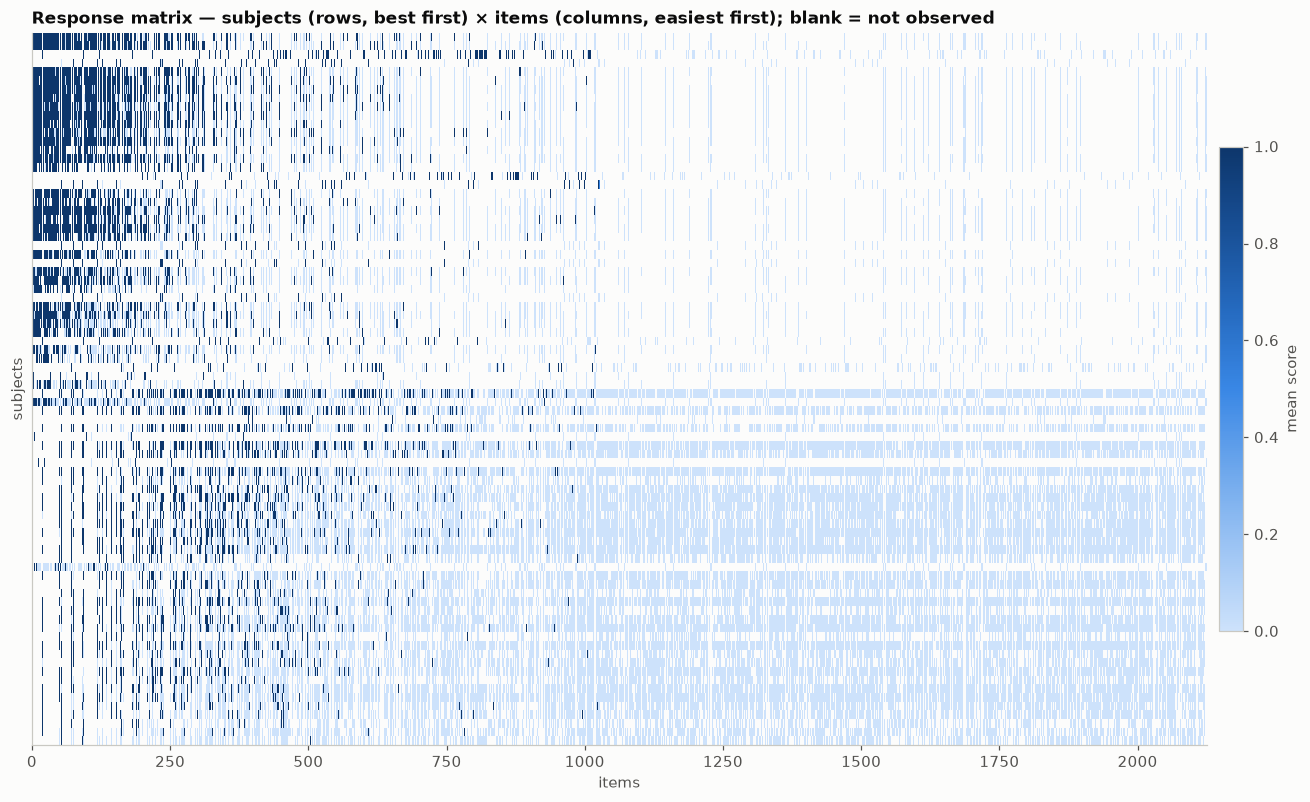

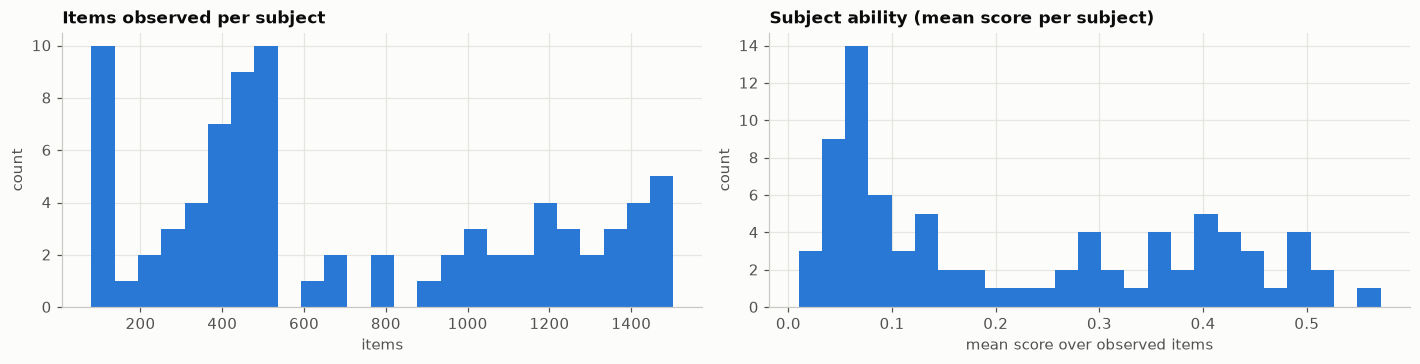

Subjects by mean score (top 10 / bottom 10). Raw means are not comparable when subjects saw different items:


,subject,mean_score,n_items
0,Claude-3.7-Sonnet · OpenHands,0.571,457
1,Gemini-2.5-Pro · Agentless,0.521,470
2,CodeArts-GLM-5.1 · CodeArts-Agent,0.510,255
3,CodeArts-MiniMax-M2.5 · CodeArts-Agent,0.500,112
4,Claude-3.7-Sonnet · SWE-agent,0.498,460
5,OpenAI-o3-mini-high · Agentless,0.493,471
6,OpenAI-o1 · Agentless,0.490,492
7,Claude-3.7-Sonnet · Agentless,0.464,481
8,Gemini-2.5-Pro · OpenHands,0.458,500
9,Doubao-1.5-thinking · Agentless,0.457,490


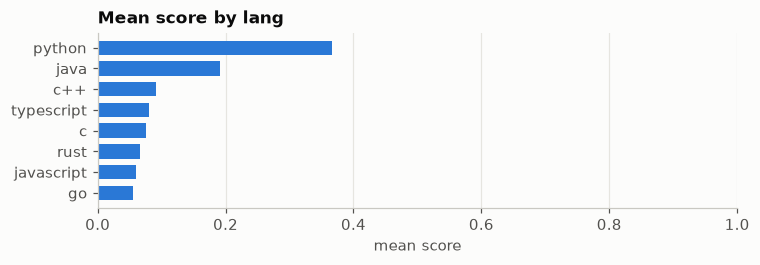

In [29]:
responses = eda_responses(B)

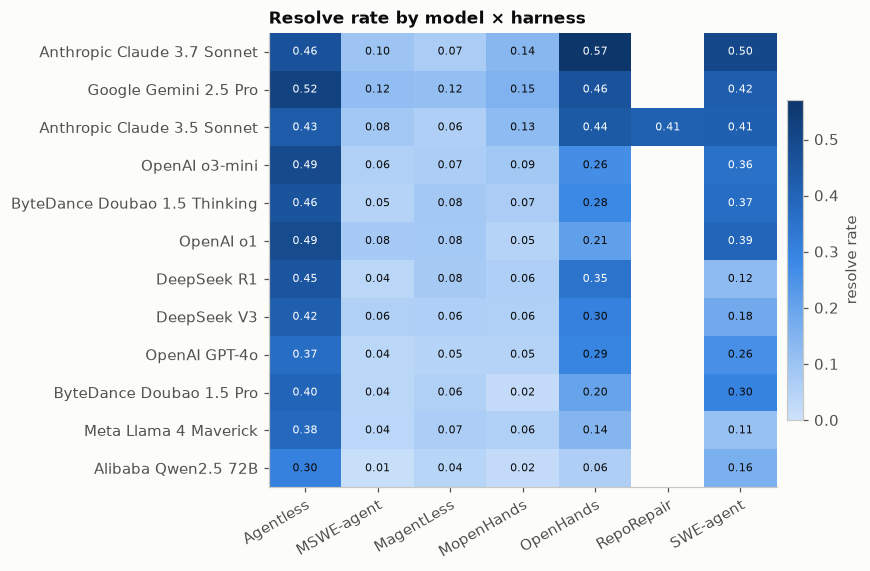

,subjects,items,resolve_rate
harness,,,
Agentless,12,500,0.433
CodeArts-Agent,2,367,0.504
InfCode,2,251,0.323
MSWE-Agent,1,119,0.280
MSWE-agent,12,1624,0.060
MagentLess,12,1605,0.070
MopenHands,12,1624,0.078
OpenHands,12,500,0.309
RepoRepair,3,592,0.230


In [ ]:
# Model × harness

rs = responses.merge(subjects[["subject_id", "normalized_name", "harness"]], on="subject_id")
grid = rs.groupby(["normalized_name", "harness"]).response.mean().unstack()
grid = grid[grid.notna().sum(axis=1) >= 3].dropna(axis=1, how="all")
grid = grid.loc[grid.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(8, 0.34 * len(grid) + 1.2))
im = ax.imshow(np.ma.masked_invalid(grid.values), cmap=SEQ, vmin=0, vmax=grid.max().max(), aspect="auto")
ax.set_xticks(range(grid.shape[1]), grid.columns, rotation=30, ha="right", rotation_mode="anchor")
ax.set_yticks(range(grid.shape[0]), grid.index)
ax.grid(False)
for (i, j), v in np.ndenumerate(grid.values):
    if not np.isnan(v):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if v > 0.6 * grid.max().max() else INK)
ax.set_title("Resolve rate by model × harness")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="resolve rate")
fig.tight_layout()
plt.show()
display(rs.groupby("harness").agg(subjects=("subject_id", "nunique"), items=("item_id", "nunique"),
                                  resolve_rate=("response", "mean")).round(3))

### 4.5 traces

57,184 traces · covers 98.6% of responses · orphan traces (no response): 0
null/empty traces: 0 / 0


,count,mean,std,min,5%,50%,95%,max
chars,57184.0,10356.7,134291.4,72.0,458.0,1471.5,23010.9,12708024.0
lines,57184.0,256.6,3351.5,1.0,14.0,43.0,652.0,558951.0
files_in_diff,57184.0,4.2,253.5,0.0,1.0,1.0,5.0,60001.0


traces that are git diffs: 98.7%


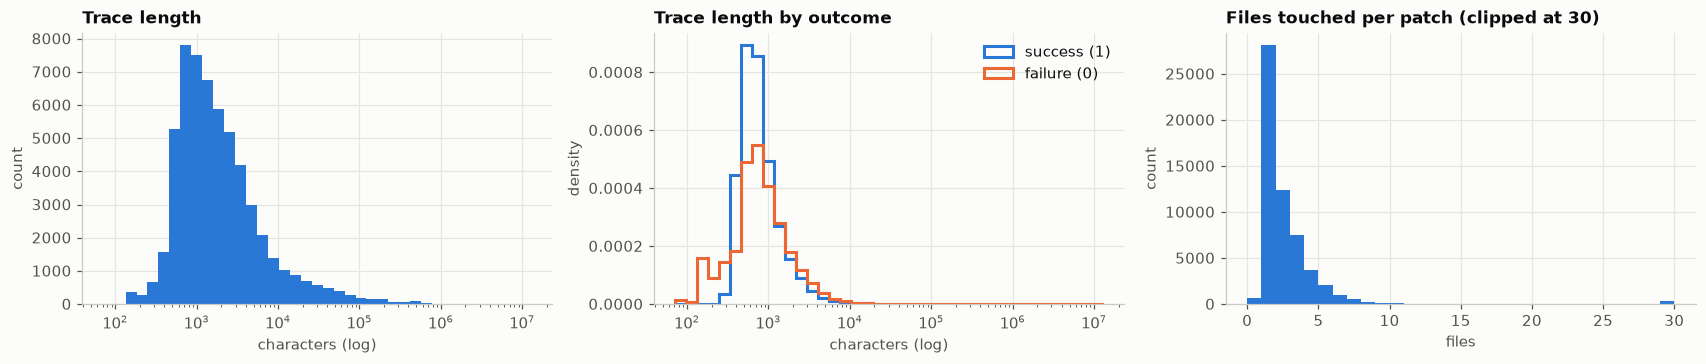

Spearman correlation(trace length, score): -0.137

--- random trace 1 (864 chars) ---
diff --git a/tracing-attributes/tests/async_move.rs b/tracing-attributes/tests/async_move.rs new file mode 100644 index 00000000..509ac9be --- /dev/null +++ b/tracing-attributes/tests/async_move.rs @@ -0,0 +1,23 @@ +#[test] +fn async_move_capture() { + use tracing::{instrument, Instrument}; + + struct Test { + metrics: usize, + } + + impl Test { + #[instrument(skip(self), fields(x))] + fn call(&self) -> std::pin::Pin<Box<dyn std::future::Future<Output = usize>>> { + let metrics = self.metrics; + Box::pin(async move { + // Verify metrics is captured from outer scope + let _ = &metrics; + …

--- random trace 2 (875 chars) ---
diff --git a/django/contrib/admin/checks.py b/django/contrib/admin/checks.py index c395b0bde2..2c90dedc31 100644 --- a/django/contrib/admin/checks.py +++ b/django/contrib/admin/checks.py @@ -771,10 +771,11 @@ class BaseModelAdminChecks: except FieldDoesNotExist: return [ checks.Err

In [31]:
traces = eda_traces(B, responses)

---
## 5. REAL web agents

In [33]:
B = "real_webagents"

### 5.1 benchmarks

In [34]:
eda_benchmarks(B)

**REAL** — nan

REAL tests whether web agents can complete user tasks on deterministic clones of real websites, counting an attempt as
successful only when every one of the task's automatic checks passes. 



,value
benchmark_id,real_webagents
name,REAL
version,NaN
license,unknown
source_url,https://realevals.xyz/api/getVerifiedModelData
modality,"[text, gui_screenshot]"
domain,[agents_and_tool_use]
multi_single_turn,multi_turn
response_type,binary
response_scale,"{""direction"":""higher_is_better"",""kind"":""discrete"",""meanings"":{""0"":""failure"",..."


### 5.2 subjects

33 subjects · subject_id unique: True · distinct normalized_name: 33


,dtype,non_null,non_null_%,n_unique,example
subject_id,str,33,100.0,33,b3a53e75aa1066aa
display_name,str,33,100.0,33,amazon/nova-act-v1.0
normalized_name,str,33,100.0,33,Amazon Nova Act
provider,str,33,100.0,10,Amazon
release_date,str,26,78.8,22,2025-03-31
access_date,str,0,0.0,0,
harness,str,0,0.0,0,
reasoning_effort,str,0,0.0,0,
harness_version,str,0,0.0,0,
subject_features_extra,str,0,0.0,0,


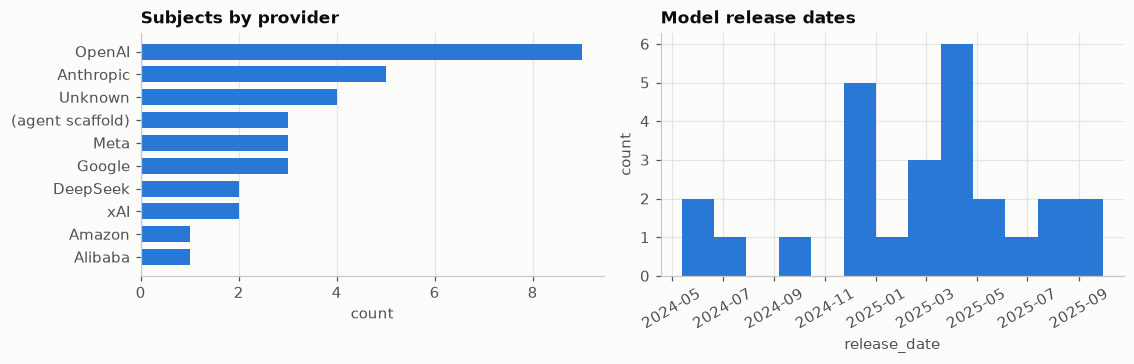

,subject_id,display_name,normalized_name,provider,release_date,access_date,harness,reasoning_effort,harness_version
0,b3a53e75aa1066aa,amazon/nova-act-v1.0,Amazon Nova Act,Amazon,2025-03-31,NaN,NaN,NaN,NaN
1,553639df45642394,GBOX,Agent: gbox,(agent scaffold),NaN,NaN,NaN,NaN,NaN
2,c68b0b4cebac1009,anthropic-computer_use,Anthropic Claude 3.5 Sonnet,Anthropic,2024-06-20,NaN,NaN,NaN,NaN
3,1a06f0f18530a417,deepseek/deepseek-v3.2-exp,DeepSeek V3.2,DeepSeek,2025-09-29,NaN,NaN,NaN,NaN
4,6842e28b19417e47,meta-llama/llama-4-maverick,Meta Llama 4 Maverick,Meta,2025-04-05,NaN,NaN,NaN,NaN
5,7fcaa05b8c908c9f,anthropic/claude-3.7-sonnet:thinking,Anthropic Claude 3.7 Sonnet,Anthropic,2025-02-24,NaN,NaN,NaN,NaN
6,94252e00abb3c60f,openai/gpt-5-nano,OpenAI GPT-5 nano,OpenAI,2025-08-07,NaN,NaN,NaN,NaN
7,ab1a57252740ac07,anthropic/claude-sonnet-4,Anthropic Claude Sonnet 4,Anthropic,2025-05-22,NaN,NaN,NaN,NaN


In [35]:
subjects = eda_subjects(B)

### 5.3 items

233 items · item_id unique: True · raw_item_id unique: True · duplicate content_hash: 0


,dtype,non_null,non_null_%,n_unique,example
item_id,str,233,100.0,233,1e830a414c464f66
benchmark_id,str,233,100.0,1,real_webagents
raw_item_id,str,233,100.0,233,v2.staynb-12
content,str,233,100.0,233,"Show me places in Delhi, India for 2 guests on the dates Se…"
asset_manifest,str,0,0.0,0,
grading_criterion,str,233,100.0,113,"{""reference_answer"":null,""rule"":""Success requires all provi…"
verifier,str,233,100.0,3,"{""class"": ""exact_matcher"", ""spec"": ""{\""kind\"": \""provider_r…"
content_hash,str,233,100.0,233,c1cf7f5ea178676b
item_features,str,233,100.0,12,website=staynb


grading_criterion keys: {'reference_answer': 233, 'rule': 233}
verifier keys: {'class': 233, 'spec': 233, 'judged_by': 60}
grading rules: {'Success requires all provider task checks to pass; task-specific checks are unavailable i…': 121, '[{"expected_value": true, "rubric": "Does the response indicate that it\'s not possible to…': 1, '[{"description": "booking was made", "expected_value": true, "query": "bookingDetailsDiff…': 1}


,n_unique,non_null,top_values
item_features key,,,
website,12,233,"{'gomail': 29, 'udriver': 25, 'dashdish': 22, 'opendining': 21}"


verifier class: {'exact_matcher': 173, 'judge': 60}


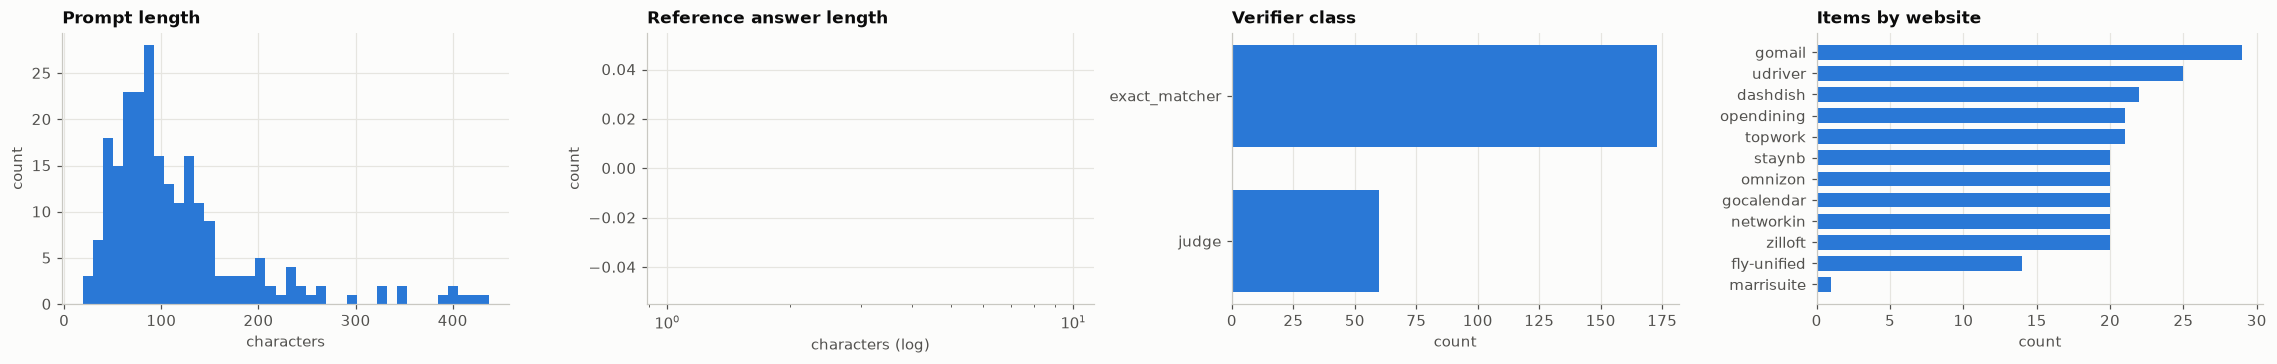

--- example item v2.staynb-12 ---
Show me places in Delhi, India for 2 guests on the dates Sept 7th to 9th.
reference answer: None
verifier: {"class": "exact_matcher", "spec": "{\"kind\": \"provider_result_mapping\", \"logic\": \"1 iff evalsFailed is empty; if absent, 1 iff accuracy >= 100; otherwise 0\", \"source\": \"https://realevals.xyz/api/getVerifiedModelData\", \"upstream_task_verifier\": \"not released in the captured v2 task sn…


In [36]:
items = eda_items(B)

### 5.4 response

4,449 responses · 33 subjects × 233 items · trials 1–5 · response_id unique: True
missing scores: 0 · duplicate (subject, item, trial, condition): 0
test_condition: {nan: 4449}
interactors: {nan: 4449}
orphans — subjects not in subjects table: 0, items not in items table: 0


subject × item matrix: 33 × 233, 48.9% of cells observed


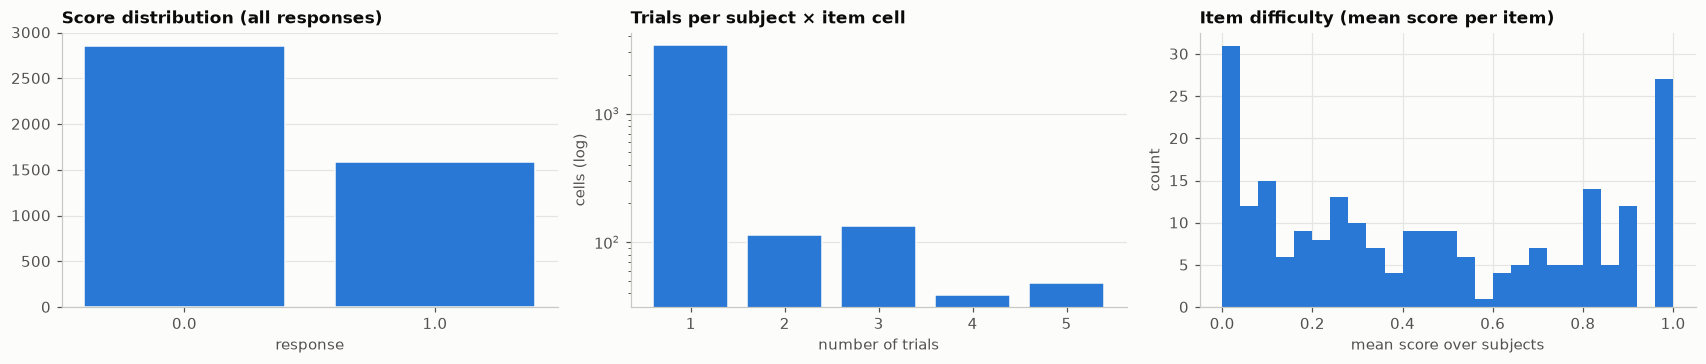

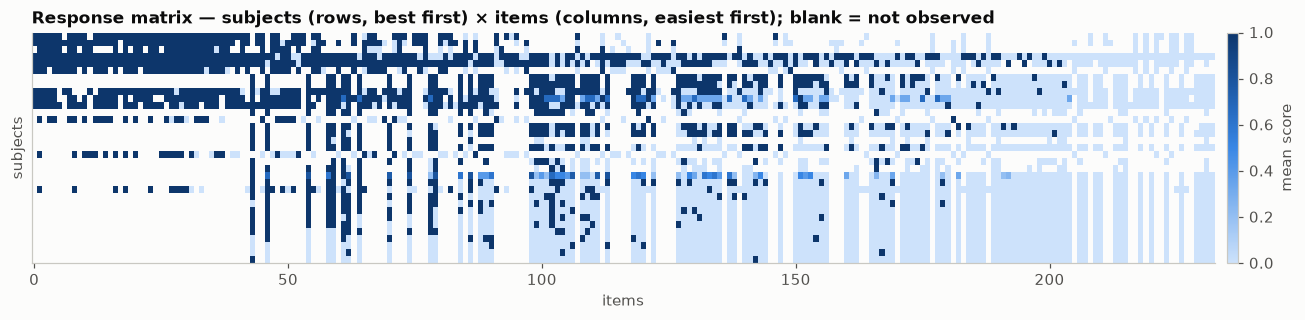

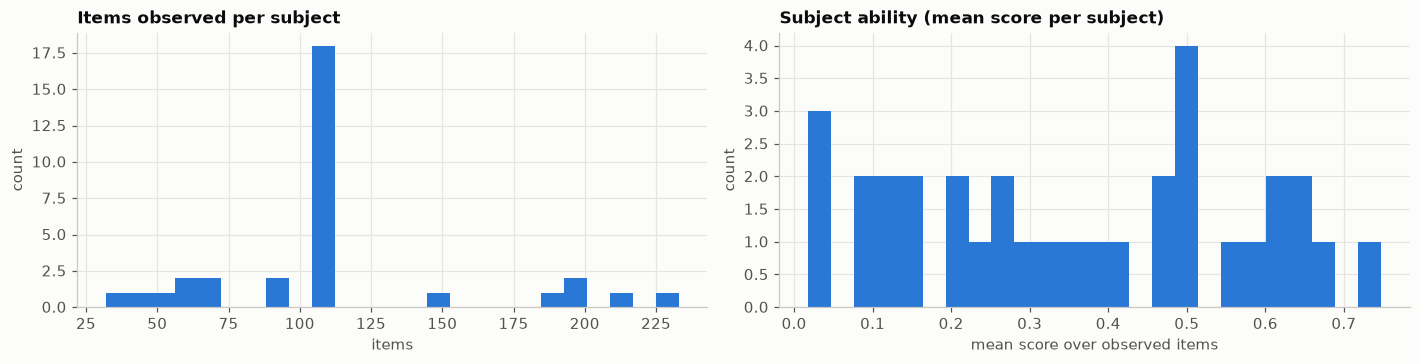

Subjects by mean score (top 10 / bottom 10). Raw means are not comparable when subjects saw different items:


,subject,mean_score,n_items
0,anthropic/claude-sonnet-4.5,0.747,91
1,google/gemini-2.5-flash,0.660,106
2,x-ai/grok-4-fast,0.643,70
3,amazon/nova-act-v1.0,0.635,233
4,anthropic-computer_use,0.620,213
5,openai/gpt-5,0.618,89
6,GBOX,0.598,112
7,KISS-1,0.571,112
8,google/gemini-2.5-pro,0.513,199
9,anthropic/claude-3.7-sonnet:thinking,0.511,190


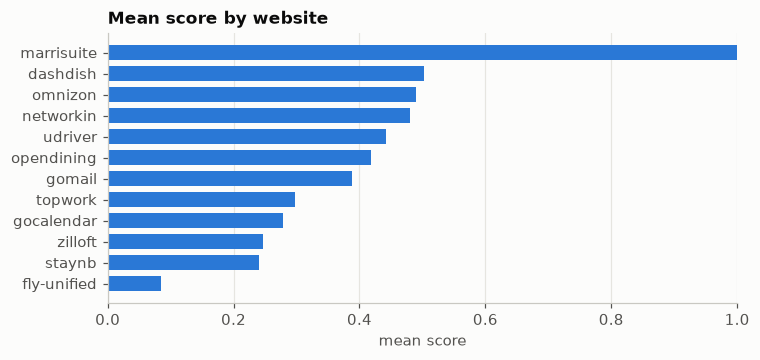

In [37]:
responses = eda_responses(B)

#### Grading type

In [38]:
vmeta = pd.DataFrame({"item_id": items.item_id, "verifier": items.verifier.map(lambda v: parse_json(v)["class"])})
display(responses.merge(vmeta, on="item_id").groupby("verifier").agg(
    items=("item_id", "nunique"), responses=("response", "size"), success_rate=("response", "mean")).round(3))

,items,responses,success_rate
verifier,,,
exact_matcher,173,2572,0.385
judge,60,1877,0.320


### 5.5 traces

1,242 traces · covers 27.9% of responses · orphan traces (no response): 0
null/empty traces: 0 / 0


,count,mean,std,min,5%,50%,95%,max
chars,1242.0,231.9,246.0,1.0,45.0,173.0,578.8,4676.0
lines,1242.0,2.2,4.6,1.0,1.0,1.0,9.0,94.0
files_in_diff,1242.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


traces that are git diffs: 0.0%


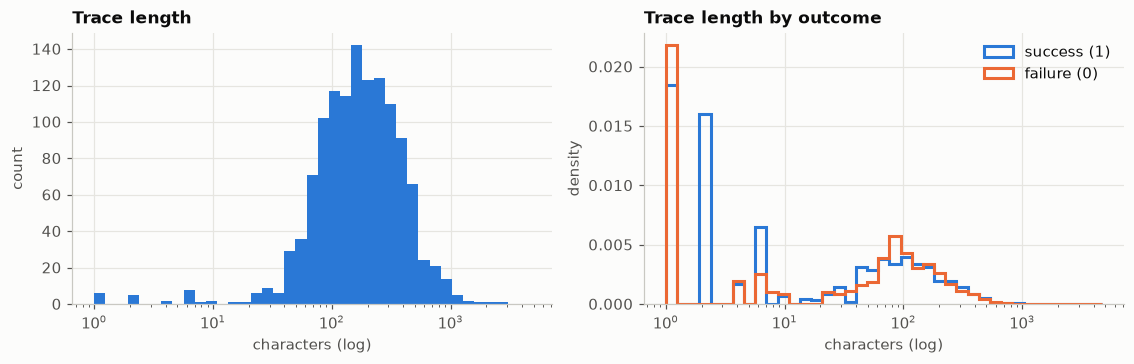

Spearman correlation(trace length, score): +0.016

--- random trace 1 (88 chars) ---
The 'Morning Coffee with sister' event is already scheduled for July 19, 2024, at 10 AM.

--- random trace 2 (77 chars) ---
I have successfully changed your default payment method to your card on file.


In [39]:
traces = eda_traces(B, responses)

---
## 6. ResearchCodeBench

In [41]:
B = "researchcodebench"

### 6.1 benchmarks

In [42]:
eda_benchmarks(B)

**ResearchCodeBench** — nan

ResearchCodeBench tests whether models can implement a missing piece of a recent machine learning paper's code, given
the paper itself and the surrounding file, with curated tests deciding whether the filled in code works. 



,value
benchmark_id,researchcodebench
name,ResearchCodeBench
version,NaN
license,unknown
source_url,https://researchcodebench.github.io/
modality,[text]
domain,"[software_engineering, ml_engineering]"
multi_single_turn,single_turn
response_type,binary
response_scale,"{""kind"":""discrete"",""values"":[0.0,1.0]}"


### 6.2 subjects

31 subjects · subject_id unique: True · distinct normalized_name: 31


,dtype,non_null,non_null_%,n_unique,example
subject_id,str,31,100.0,31,96098bb6ed439973
display_name,str,31,100.0,31,GEMINI_2_0_FLASH
normalized_name,str,31,100.0,31,Google Gemini 2.0 Flash
provider,str,31,100.0,10,Google
release_date,str,31,100.0,26,2024-12-11
access_date,str,0,0.0,0,
harness,str,0,0.0,0,
reasoning_effort,str,0,0.0,0,
harness_version,str,0,0.0,0,
subject_features_extra,str,0,0.0,0,


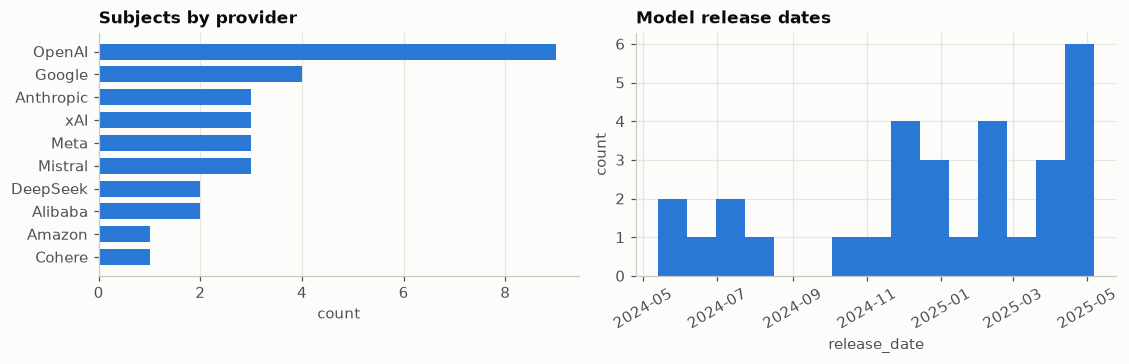

,subject_id,display_name,normalized_name,provider,release_date,access_date,harness,reasoning_effort,harness_version
0,96098bb6ed439973,GEMINI_2_0_FLASH,Google Gemini 2.0 Flash,Google,2024-12-11,NaN,NaN,NaN,NaN
1,b8d2171afab2c063,GPT_4O_2024_08_06,OpenAI GPT-4o,OpenAI,2024-05-13,NaN,NaN,NaN,NaN
2,1ba99d7bfc77bdf7,GPT_4O_MINI,OpenAI GPT-4o mini,OpenAI,2024-07-18,NaN,NaN,NaN,NaN
3,8d0f7b00fa1ee7d4,O3_MINI_HIGH,OpenAI o3-mini,OpenAI,2024-12-20,NaN,NaN,NaN,NaN
4,50cbacf8db8037c0,DEEPSEEK_R1,DeepSeek R1,DeepSeek,2025-01-20,NaN,NaN,NaN,NaN
5,a710d3c9478ce52e,O1_HIGH,OpenAI o1,OpenAI,2024-12-05,NaN,NaN,NaN,NaN
6,7facc3df28eab6df,GPT_4_1,OpenAI GPT-4.1,OpenAI,2025-04-14,NaN,NaN,NaN,NaN
7,0b840a32283e38bc,GPT_4_1_MINI,OpenAI GPT-4.1 mini,OpenAI,2025-04-14,NaN,NaN,NaN,NaN


In [43]:
subjects = eda_subjects(B)

### 6.3 items

212 items · item_id unique: True · raw_item_id unique: True · duplicate content_hash: 0


,dtype,non_null,non_null_%,n_unique,example
item_id,str,212,100.0,212,f22272d259fbf367
benchmark_id,str,212,100.0,1,researchcodebench
raw_item_id,str,212,100.0,212,advantage-alignment::aa_terms3
content,str,212,100.0,212,⏎ You are an expert in reproducing research code from a pa…
asset_manifest,str,0,0.0,0,
grading_criterion,str,212,100.0,212,"{""reference_answer"":"" A_1s = torch.cumsum(A_s[:, :-1…"
verifier,str,212,100.0,1,"{""class"": ""exact_matcher"", ""spec"": ""Provider's pinned greed…"
content_hash,str,212,100.0,212,44ac1cee501a5b60
item_features,str,212,100.0,20,paper=advantage-alignment


grading_criterion keys: {'reference_answer': 212, 'rule': 212}
verifier keys: {'class': 212, 'spec': 212}
grading rules: {"Assign 1 when the provider's paper-specific tests pass, otherwise 0.": 212}


,n_unique,non_null,top_values
item_features key,,,
paper,20,212,"{'eomt': 37, 'GMFlow': 16, 'grid-cell-conformal-isometry': 15, 'llm-sci-use'..."


verifier class: {'exact_matcher': 212}


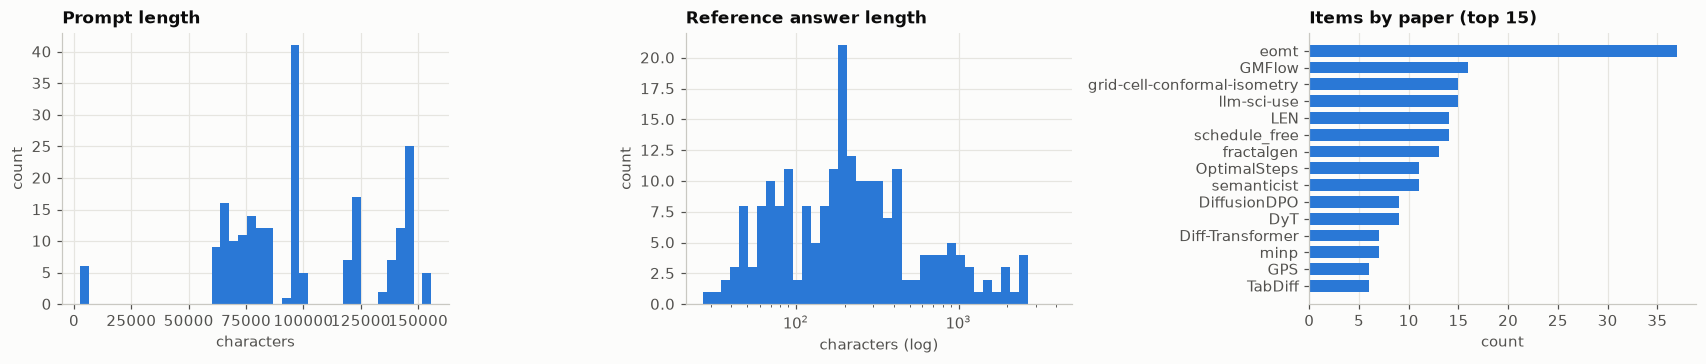

--- example item advantage-alignment::aa_terms3 ---
You are an expert in reproducing research code from a paper. Here is the paper that you need to use to complete the code: \documentclass{article} \usepackage{iclr2025_conference,times} \usepackage{amsmath,amsfonts,bm} \newcommand{\figleft}{{\em (Left)}} \newcommand{\figcenter}{{\em (Center)}} \newcommand{\figright}{{\em (Right)}} \newcommand{\figtop}{{\em (Top)}} \newcommand{\figbottom}{{\em (Bottom)}} \newcommand{\captiona}{{\em (a)}} \newcommand{\captionb}{{\em (b)}} \newcommand{\captionc}{{\em (c)}} \newcommand{\captiond}{{\em (d)}} \newcommand{\newterm}[1]{{\bf #1}} \def\figref#1{figure~\ref{#1}} \def\Figref#1{Figure~\ref{#1}} \def\twofigref#1#2{figures \ref{#1} and \ref{#2}} …
reference answer:         A_1s = torch.cumsum(A_s[:, :-1], dim=1) ⏎         A_s = A_s[:, 1:] ⏎         def other_A_s(A_s, N): ⏎             mask = torch.ones((N, N), device=device) - torch.eye(N, device=device) ⏎             # mask[:, -(N-n):] = 0   # To tu

In [44]:
items = eda_items(B)

### 6.4 response

6,784 responses · 31 subjects × 212 items · trials 1–2 · response_id unique: True
missing scores: 0 · duplicate (subject, item, trial, condition): 0
test_condition: {nan: 6784}
interactors: {nan: 6784}
orphans — subjects not in subjects table: 0, items not in items table: 0
subject × item matrix: 31 × 212, 100.0% of cells observed


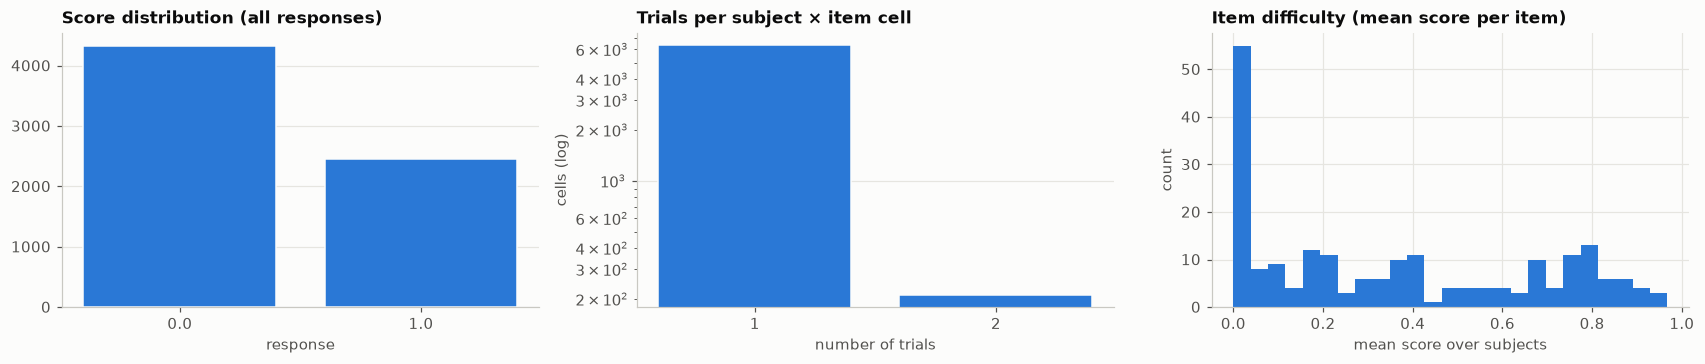

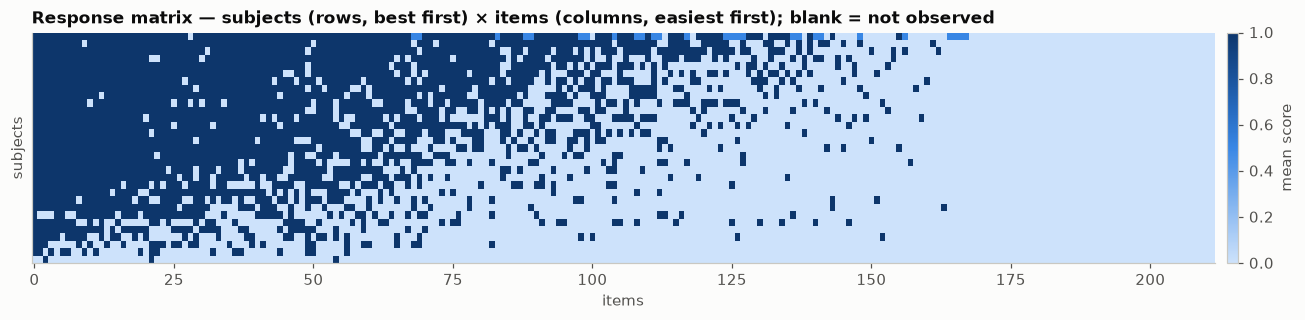

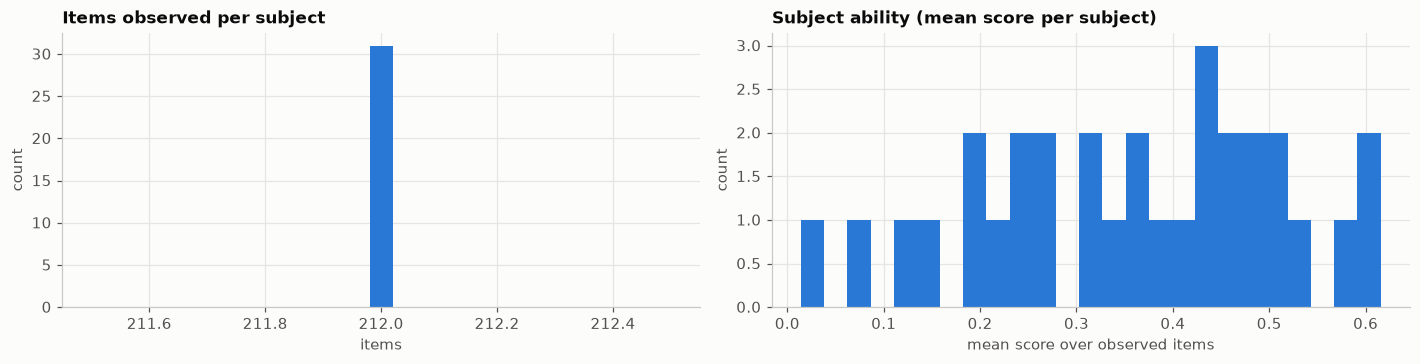

Subjects by mean score (top 10 / bottom 10). Raw means are not comparable when subjects saw different items:


,subject,mean_score,n_items
0,GEMINI_2_5_PRO_PREVIEW_03_25,0.616,212
1,O3_HIGH,0.594,212
2,OPENROUTER_O4_MINI_HIGH,0.585,212
3,O3_MINI_HIGH,0.524,212
4,CLAUDE_3_7_SONNET_2025_02_19,0.519,212
5,GPT_4_1,0.500,212
6,CLAUDE_3_5_SONNET_2024_10_22,0.486,212
7,O1_HIGH,0.481,212
8,DEEPSEEK_R1,0.458,212
9,GEMINI_2_5_FLASH_PREVIEW_04_17,0.453,212


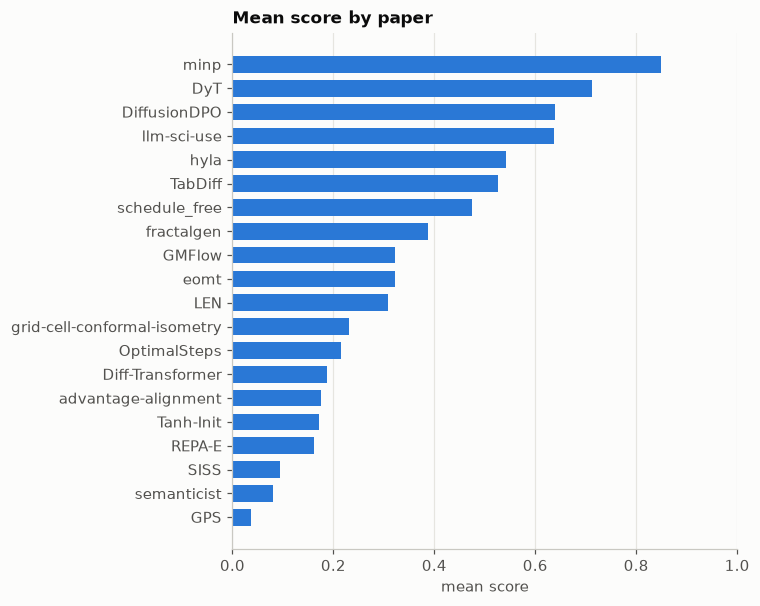

In [45]:
responses = eda_responses(B)

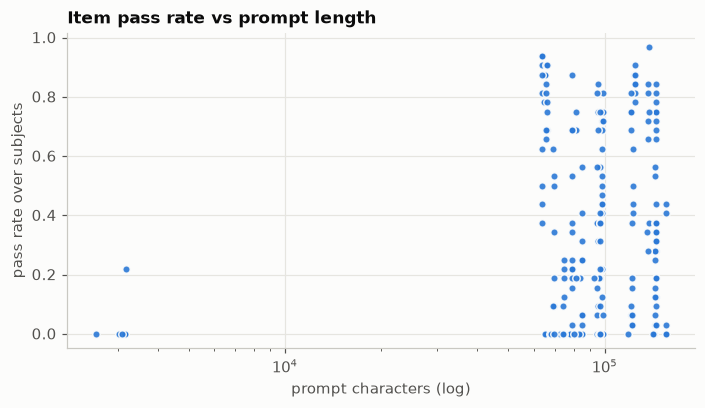

Spearman: +0.104


In [ ]:
# Prompt length vs difficulty
item_stats = (responses.groupby("item_id").response.mean().rename("pass_rate").to_frame()
              .join(items.set_index("item_id").content.str.len().rename("prompt_chars")))
fig, axes = panels(1, width=6.5, height=3.8)
axes[0].scatter(item_stats.prompt_chars, item_stats.pass_rate, s=24, color=BLUE, edgecolor=SURFACE, linewidth=1, alpha=0.9)
axes[0].set_xscale("log")
axes[0].set_xlabel("prompt characters (log)")
axes[0].set_ylabel("pass rate over subjects")
axes[0].set_title("Item pass rate vs prompt length")
fig.tight_layout()
plt.show()
print(f"Spearman: {item_stats.corr(method='spearman').iloc[0, 1]:+.3f}")

---
## 7. SWE-rebench

In [49]:
B = "swe_rebench"

### 7.1 benchmarks

In [50]:
eda_benchmarks(B)

**SWE-rebench** — nan

SWE-rebench: an automated, decontaminated benchmark of real-world software-engineering agent tasks. Each task is a
GitHub issue + repo snapshot; an LLM agent must produce a patch verified by the repo test suite (FAIL_TO_PASS /
PASS_TO_PASS). This build ingests the publicly released per-instance trajectories of the OpenHands v0.54.0 +
Qwen3-Coder-480B-A35B-Instruct agent, emitting a binary resolved=1/0 response per (agent, instance, run). 



,value
benchmark_id,swe_rebench
name,SWE-rebench
version,NaN
license,CC-BY-4.0
source_url,https://huggingface.co/datasets/nebius/SWE-rebench-openhands-trajectories
modality,[text]
domain,"[software_engineering, agents_and_tool_use]"
multi_single_turn,multi_turn
response_type,binary
response_scale,"{""direction"":""higher_is_better"",""kind"":""discrete"",""meanings"":{""0"":""failure"",..."


### 7.2 subjects

In [51]:
subjects = eda_subjects(B)

1 subjects · subject_id unique: True · distinct normalized_name: 1


,dtype,non_null,non_null_%,n_unique,example
subject_id,str,1,100.0,1,58c3de46be1beb60
display_name,str,1,100.0,1,Qwen3-Coder-480B-A35B-Instruct
normalized_name,str,1,100.0,1,Alibaba Qwen3-Coder 480B
provider,str,1,100.0,1,Alibaba
release_date,str,1,100.0,1,2025-07-22
access_date,str,0,0.0,0,
harness,str,1,100.0,1,OpenHands
reasoning_effort,str,0,0.0,0,
harness_version,str,1,100.0,1,v0.54.0
subject_features_extra,str,0,0.0,0,


,subject_id,display_name,normalized_name,provider,release_date,access_date,harness,reasoning_effort,harness_version
0,58c3de46be1beb60,Qwen3-Coder-480B-A35B-Instruct,Alibaba Qwen3-Coder 480B,Alibaba,2025-07-22,NaN,OpenHands,NaN,v0.54.0


### 7.3 items

6,306 items · item_id unique: True · raw_item_id unique: True · duplicate content_hash: 35


,dtype,non_null,non_null_%,n_unique,example
item_id,str,6306,100.0,6306,0a578b6eaa4c906b
benchmark_id,str,6306,100.0,1,swe_rebench
raw_item_id,str,6306,100.0,6306,PlasmaFAIR__sdf-xarray-24
content,str,6306,100.0,6271,Forward slashes in variable names when writing to netcdf ⏎ …
asset_manifest,str,0,0.0,0,
grading_criterion,str,6306,100.0,6304,"{""reference_answer"":""diff --git a/README.md b/README.md\nin…"
verifier,str,6306,100.0,6306,"{""class"": ""exact_matcher"", ""spec"": ""{\""FAIL_TO_PASS\"": [\""t…"
content_hash,str,6306,100.0,6271,f68aee8bcbfa404f
item_features,str,0,0.0,0,


grading_criterion keys: {'reference_answer': 6306, 'rule': 6306}
verifier keys: {'class': 6306, 'spec': 6306}
grading rules: {'apply test_patch; FAIL_TO_PASS (1) must pass and PASS_TO_PASS (12) must still pass: FAIL_…': 5, 'apply test_patch; FAIL_TO_PASS (1) must pass and PASS_TO_PASS (10) must still pass: FAIL_…': 5, 'apply test_patch; FAIL_TO_PASS (1) must pass and PASS_TO_PASS (4) must still pass: FAIL_T…': 4, 'apply test_patch; FAIL_TO_PASS (1) must pass and PASS_TO_PASS (36) must still pass: FAIL_…': 4}
verifier class: {'exact_matcher': 6306}


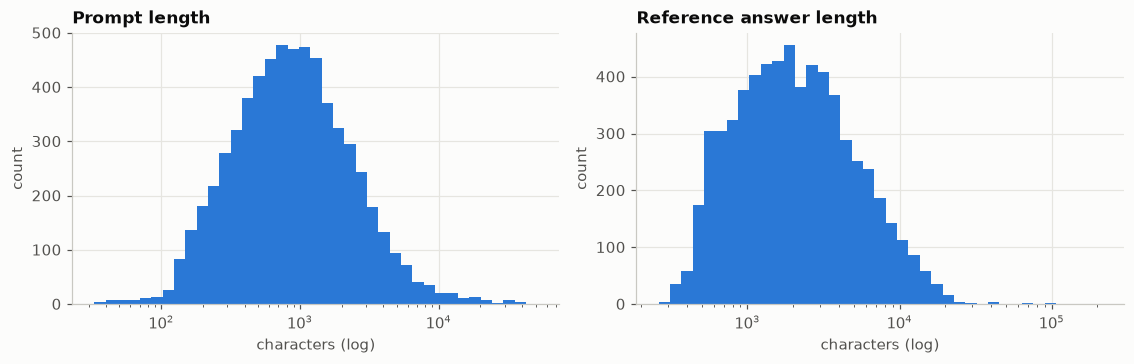

--- example item PlasmaFAIR__sdf-xarray-24 ---
Forward slashes in variable names when writing to netcdf ``` ValueError: Forward slashes '/' are not allowed in variable and dimension names (got 'Electric Field/Ex'). Forward slashes are used as hierarchy-separators for HDF5-based files ('netcdf4'/'h5netcdf'). ``` Either mangle names, or just strip first part off and add to `long_name` attribute?
reference answer: diff --git a/README.md b/README.md ⏎ index b24d80a..730da55 100644 ⏎ --- a/README.md ⏎ +++ b/README.md ⏎ @@ -4,6 +4,11 @@ ⏎  read SDF files as created by the [EPOCH](https://epochpic.github.io) ⏎  plasma PIC code. ⏎   ⏎ +> ![IMPORTANT] ⏎ +> All variable names now use snake_case to align with Epoch’…
verifier: {"class": "exact_matcher", "spec": "{\"FAIL_TO_PASS\": [\"tests/test_basic.py::test_basic\", \"tests/test_basic.py::test_constant_name_and_units\", \"tests/test_basic.py::test_coords\", \"tests/test_basic.py::test_particles\", \"tests/test_basic.py::test_multiple_files_one_

In [52]:
items = eda_items(B)

### 7.4 response

67,074 responses · 1 subjects × 6,306 items · trials 1–34 · response_id unique: True
missing scores: 0 · duplicate (subject, item, trial, condition): 0
test_condition: {nan: 67074}
interactors: {nan: 67074}


orphans — subjects not in subjects table: 0, items not in items table: 0
subject × item matrix: 1 × 6,306, 100.0% of cells observed


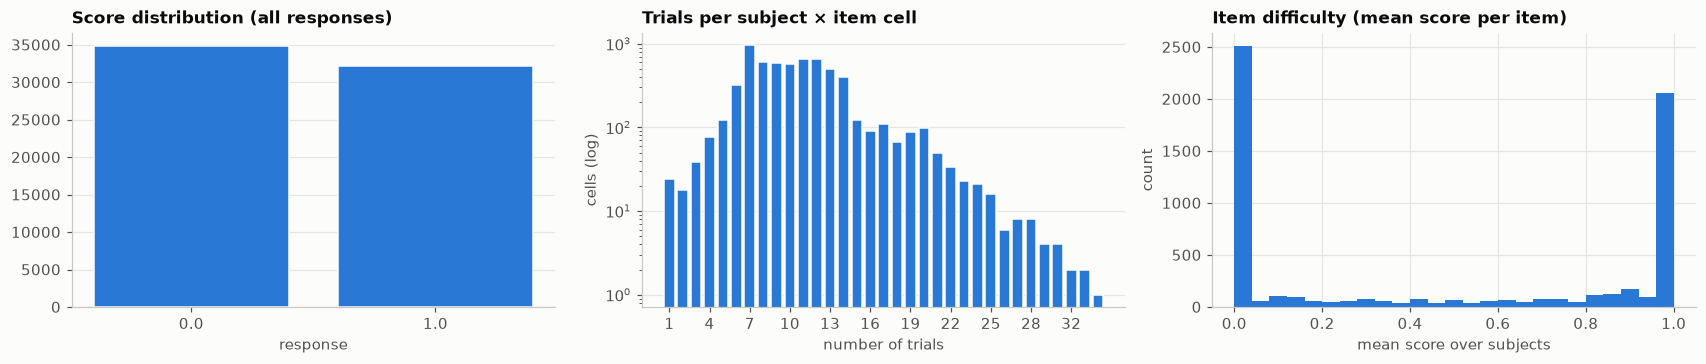

In [53]:
responses = eda_responses(B)

items always solved: 32.5% · never solved: 39.9% · mixed: 27.6%


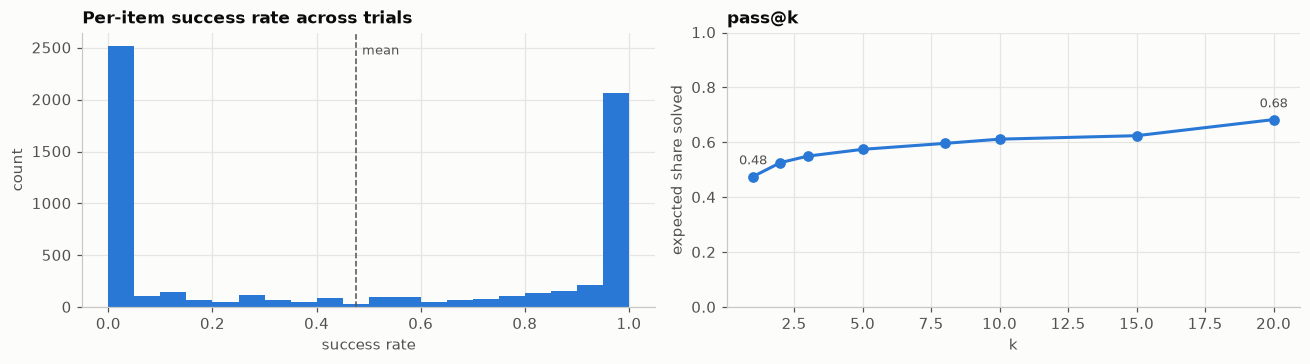

In [ ]:
# Run-to-run variance and pass@k
per_item = responses.groupby("item_id").response.agg(n="size", c="sum")
per_item["rate"] = per_item.c / per_item.n
always, never = (per_item.rate == 1).mean(), (per_item.rate == 0).mean()
print(f"items always solved: {always:.1%} · never solved: {never:.1%} · mixed: {1 - always - never:.1%}")


def pass_at_k(n, c, k):
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))


ks = [1, 2, 3, 5, 8, 10, 15, 20]
curve = pd.Series({k: per_item[per_item.n >= k].apply(lambda r: pass_at_k(r.n, r.c, k), axis=1).mean() for k in ks})
fig, axes = panels(2, width=6)
hist(axes[0], per_item.rate, "Per-item success rate across trials", "success rate", bins=20)
axes[0].axvline(per_item.rate.mean(), color=INK2, linestyle="--", linewidth=1)
axes[0].annotate("mean", (per_item.rate.mean(), axes[0].get_ylim()[1] * 0.92), xytext=(4, 0),
                 textcoords="offset points", color=INK2, fontsize=8.5)
axes[1].plot(curve.index, curve.values, color=BLUE, linewidth=2, marker="o", markersize=6)
for k in [1, ks[-1]]:
    axes[1].annotate(f"{curve[k]:.2f}", (k, curve[k]), xytext=(0, 8), textcoords="offset points", ha="center",
                     color=INK2, fontsize=8.5)
axes[1].set_ylim(0, 1)
axes[1].set_title("pass@k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("expected share solved")
fig.tight_layout()
plt.show()

### 7.5 traces

67,018 traces · covers 99.9% of responses · orphan traces (no response): 0
null/empty traces: 0 / 0


,count,mean,std,min,5%,50%,95%,max
chars,67018.0,10725.2,13207.7,154.0,602.0,4574.5,35543.0,127953.0
lines,67018.0,299.9,378.5,7.0,14.0,113.0,1003.1,4624.0
files_in_diff,67018.0,4.5,4.9,1.0,1.0,3.0,13.0,328.0


traces that are git diffs: 100.0%


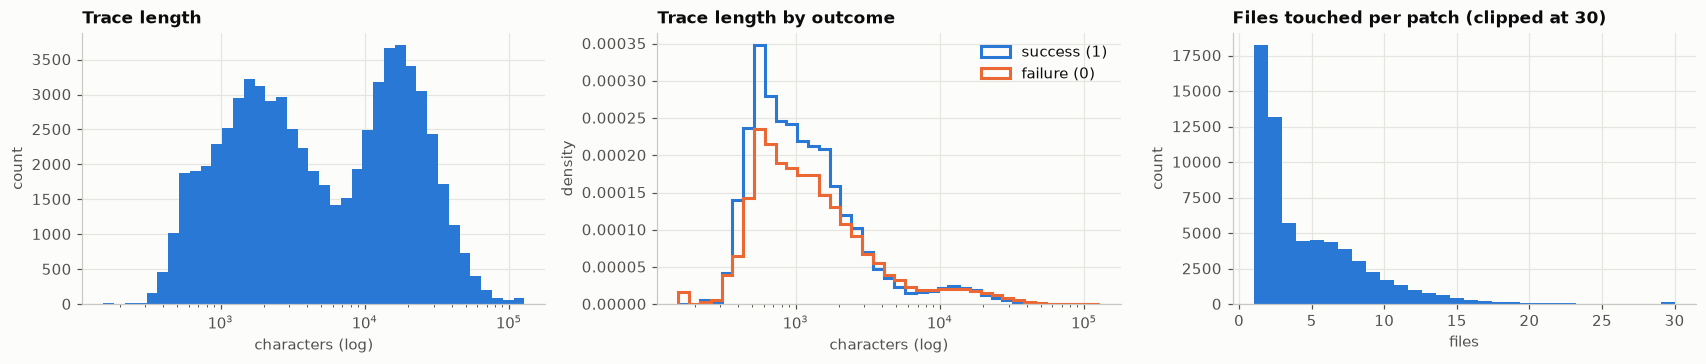

Spearman correlation(trace length, score): -0.122

--- random trace 1 (29,011 chars) ---
diff --git a/comprehensive_test.py b/comprehensive_test.py new file mode 100644 index 0000000..8d281cf --- /dev/null +++ b/comprehensive_test.py @@ -0,0 +1,124 @@ +#!/usr/bin/env python3 + +""" +Comprehensive test of the new SELECT auto-detection feature. +""" + +from io import StringIO +from sqlvalidator import file_formatter + +def test_case(name, input_content, expected_content, expected_changes): + """Test a specific case.""" + print(f"=== {name} ===") + print(f"Input: {repr(input_content)}") + + input_file = StringIO(input_content) + num_changed_sql, actual_content = …

--- random trace 2 (3,068 chars) ---
diff --git a/.openhands/TASKS.md b/.openhands/TASKS.md new file mode 100644 index 0000000..4a08ed4 --- /dev/null +++ b/.openhands/TASKS.md @@ -0,0 +1,11 @@ +# Task List + +1. ✅ Analyze the root cause of the ECB block alignment issue +Identified that rjust(32) padding doesn't account for UTF-

In [55]:
traces = eda_traces(B, responses)